# Analyzing Electric Vehicle Adoption and Identifying Key Market Drivers
# Using Machine Learning Techniques on Large-Scale Vehicle Registration Data


**Course:** QM640 Data Analytics Capstone — Walsh College  
**Student Name :** J Dhilip Kumar

**Mentor       :** Mr. Jainesh Garg

**Dataset:** Washington State Electric Vehicle Population Data  
**Source:** https://data.wa.gov/Transportation/Electric-Vehicle-Population-Data/f6w7-q2d2  
**GitHub:** https://github.com/JDhilip16/EV-Adoption-Analysis-ML

---
### Research Questions
- **RQ1:** Which vehicle and regional characteristics are statistically significant in explaining EV type classification?
- **RQ2:** How do different ML models compare in predicting EV type (BEV vs PHEV)?
- **RQ3:** Does class imbalance handling (SMOTE, class weighting) improve model performance?
- **RQ4:** What are the most important features influencing EV type selection?

### Target Variable
**Electric Vehicle Type:** Battery Electric Vehicle (BEV) vs Plug-in Hybrid Electric Vehicle (PHEV)

## Section 0 — Install and Import Libraries

In [1]:
# Install required libraries (run once)
!pip install imbalanced-learn shap -q

In [2]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Statistical analysis
from scipy import stats
from scipy.stats import chi2_contingency, pointbiserialr
import statsmodels.api as sm

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

# Imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# SHAP
import shap

# Display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
sns.set_palette('muted')

print('All libraries loaded successfully.')

All libraries loaded successfully.


## Section 1 — Data Collection and Initial Inspection

In [3]:
# ── UPLOAD INSTRUCTIONS ───────────────────────────────────────────────────────
# Option A (Colab): Upload the CSV file using the Files panel on the left
# Option B (Colab): Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
FILE_PATH = "/content/drive/MyDrive/Colab_Notebooks/AIML/Electric_Vehicle_Population_Data_20260410.csv"


df_raw = pd.read_csv(FILE_PATH)
print(f'Dataset loaded: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
df_raw.head(3)

Mounted at /content/drive
Dataset loaded: 279,780 rows x 16 columns


,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,JN1AZ0CP5C,Stevens,Colville,WA,99114.0,2012,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73.0,7.0,153331706,POINT (-117.90454 48.54657),AVISTA CORP,5.306595e+10
1,JTMABABA7P,Yakima,Yakima,WA,98903.0,2023,SUBARU,SOLTERRA,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,15.0,253586308,POINT (-120.71847 46.55029),PACIFICORP,5.307700e+10
2,1N4AZ1CP1J,King,Seattle,WA,98122.0,2018,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,151.0,37.0,333135022,POINT (-122.31009 47.60803),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10


In [4]:
# Dataset overview
print('=== COLUMN TYPES ===')
print(df_raw.dtypes)
print('\n=== BASIC STATISTICS ===')
df_raw.describe(include='all').T

=== COLUMN TYPES ===
VIN (1-10)                                            object
County                                                object
City                                                  object
State                                                 object
Postal Code                                          float64
Model Year                                             int64
Make                                                  object
Model                                                 object
Electric Vehicle Type                                 object
Clean Alternative Fuel Vehicle (CAFV) Eligibility     object
Electric Range                                       float64
Legislative District                                 float64
DOL Vehicle ID                                         int64
Vehicle Location                                      object
Electric Utility                                      object
2020 Census Tract                                    float64
dty

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
VIN (1-10),279780,17072,7SAYGDEE7P,1187,NaN,NaN,NaN,NaN,NaN,NaN,NaN
County,279756,253,King,138130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,279756,894,Seattle,43250,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,279780,52,WA,279093,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Postal Code,279756.0,NaN,NaN,NaN,98176.111447,2577.39804,1030.0,98052.0,98133.0,98382.0,99517.0
Model Year,279780.0,NaN,NaN,NaN,2022.074072,3.059852,1999.0,2021.0,2023.0,2024.0,2027.0
Make,279780,47,TESLA,114847,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model,279780,187,MODEL Y,60035,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Electric Vehicle Type,279780,2,Battery Electric Vehicle (BEV),223884,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Clean Alternative Fuel Vehicle (CAFV) Eligibility,279780,3,Eligibility unknown as battery range has not b...,177937,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Target variable distribution
ev_counts = df_raw['Electric Vehicle Type'].value_counts()
ev_pct    = df_raw['Electric Vehicle Type'].value_counts(normalize=True) * 100
print('=== TARGET VARIABLE: Electric Vehicle Type ===')
for label in ev_counts.index:
    print(f'  {label}: {ev_counts[label]:,} ({ev_pct[label]:.2f}%)')
print(f'\nClass Imbalance Ratio (BEV:PHEV) ≈ {ev_pct.iloc[0]/ev_pct.iloc[1]:.1f}:1')

=== TARGET VARIABLE: Electric Vehicle Type ===
  Battery Electric Vehicle (BEV): 223,884 (80.02%)
  Plug-in Hybrid Electric Vehicle (PHEV): 55,896 (19.98%)

Class Imbalance Ratio (BEV:PHEV) ≈ 4.0:1


## Section 2 — Data Cleaning

In [6]:
# Work on a copy
df = df_raw.copy()

# STEP 1: Missing value check
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(4)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print('=== MISSING VALUES BEFORE CLEANING ===')
print(missing_df.to_string())

=== MISSING VALUES BEFORE CLEANING ===
                      Missing Count  Missing %
Legislative District            700     0.2502
Vehicle Location                109     0.0390
County                           24     0.0086
City                             24     0.0086
Electric Utility                 24     0.0086
Postal Code                      24     0.0086
2020 Census Tract                24     0.0086
Electric Range                   11     0.0039


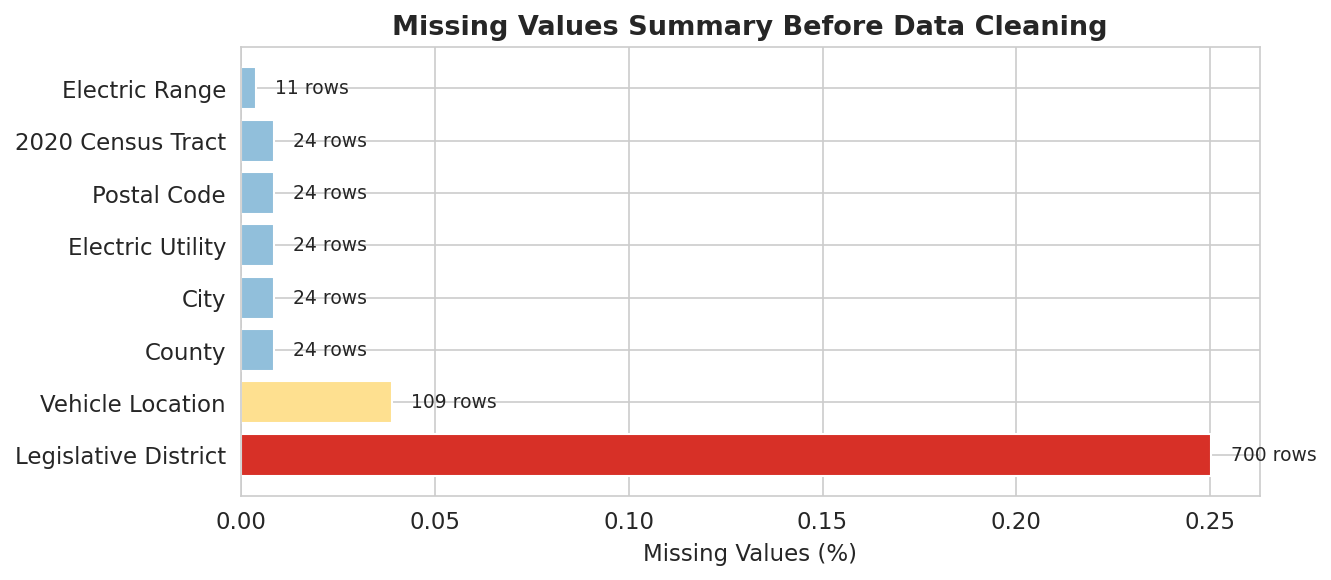

Figure saved: fig_missing_values.png


In [7]:
# STEP 2: Visualize missing values
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#d73027' if p > 0.1 else '#fee090' if p > 0.01 else '#91bfdb'
          for p in missing_df['Missing %']]
bars = ax.barh(missing_df.index, missing_df['Missing %'], color=colors, edgecolor='white')
ax.set_xlabel('Missing Values (%)')
ax.set_title('Missing Values Summary Before Data Cleaning', fontsize=13, fontweight='bold')
for bar, val in zip(bars, missing_df['Missing Count']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:,} rows', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_missing_values.png')

In [8]:
# STEP 3: Apply cleaning treatments

# Categorical mode imputation (County, City, Postal Code, Electric Utility, 2020 Census Tract)
cat_impute_cols = ['County', 'City', 'Postal Code', 'Electric Utility', '2020 Census Tract']
for col in cat_impute_cols:
    mode_val = df[col].mode()[0]
    filled = df[col].isnull().sum()
    df[col].fillna(mode_val, inplace=True)
    print(f'[Mode imputed] {col}: {filled} records filled with "{mode_val}"')

# Legislative District — median imputation (numerical)
ld_median = df['Legislative District'].median()
ld_filled = df['Legislative District'].isnull().sum()
df['Legislative District'].fillna(ld_median, inplace=True)
print(f'[Median imputed] Legislative District: {ld_filled} records filled with {ld_median}')

# Electric Range — median imputation per EV type subgroup
for ev_type in df['Electric Vehicle Type'].unique():
    mask = df['Electric Vehicle Type'] == ev_type
    subgroup_median = df.loc[mask, 'Electric Range'].median()
    null_count = df.loc[mask, 'Electric Range'].isnull().sum()
    df.loc[mask & df['Electric Range'].isnull(), 'Electric Range'] = subgroup_median
    print(f'[Subgroup median imputed] Electric Range ({ev_type}): {null_count} records filled with {subgroup_median}')

# Vehicle Location — drop from modeling (not used as predictor)
# Retained in df for mapping only

print('\n✓ All imputation steps complete.')

[Mode imputed] County: 24 records filled with "King"
[Mode imputed] City: 24 records filled with "Seattle"
[Mode imputed] Postal Code: 24 records filled with "98052.0"
[Mode imputed] Electric Utility: 24 records filled with "PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)"
[Mode imputed] 2020 Census Tract: 24 records filled with "53033028200.0"
[Median imputed] Legislative District: 700 records filled with 32.0
[Subgroup median imputed] Electric Range (Battery Electric Vehicle (BEV)): 0 records filled with 0.0
[Subgroup median imputed] Electric Range (Plug-in Hybrid Electric Vehicle (PHEV)): 11 records filled with 32.0

✓ All imputation steps complete.


In [9]:
# STEP 4: Duplicate check
dup_count = df.duplicated().sum()
print(f'Duplicate records: {dup_count}')
if dup_count > 0:
    df.drop_duplicates(inplace=True)
    print(f'Duplicates removed. New shape: {df.shape}')
else:
    print('No duplicates found. Dataset integrity confirmed.')

Duplicate records: 0
No duplicates found. Dataset integrity confirmed.


In [10]:
# STEP 5: Constant column check
for col in df.columns:
    if df[col].nunique() == 1:
        print(f'Constant column found (excluded from modeling): {col} = {df[col].unique()[0]}')

# ── STEP 6: Electric Range = 0 audit ─────────────────────────────────────────
zero_range = (df['Electric Range'] == 0)
print(f'\nElectric Range = 0 records: {zero_range.sum():,}')
print('Cross-tab with CAFV Eligibility:')
print(df[zero_range]['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].value_counts())
print('\nAll zero-range records are BEVs with unresearched battery eligibility.')
print('These are NOT missing values — retained and flagged with engineered feature.')


Electric Range = 0 records: 177,937
Cross-tab with CAFV Eligibility:
Clean Alternative Fuel Vehicle (CAFV) Eligibility
Eligibility unknown as battery range has not been researched    177937
Name: count, dtype: int64

All zero-range records are BEVs with unresearched battery eligibility.
These are NOT missing values — retained and flagged with engineered feature.


In [11]:
# STEP 7: Post-cleaning check
print('=== POST-CLEANING MISSING VALUE CHECK ===')
remaining = df.isnull().sum()
print(remaining[remaining > 0] if remaining.sum() > 0 else 'No missing values remaining.')
print(f'\nFinal dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns')

=== POST-CLEANING MISSING VALUE CHECK ===
Vehicle Location    109
dtype: int64

Final dataset shape: 279,780 rows x 16 columns


## Section 3 — Exploratory Data Analysis (EDA)

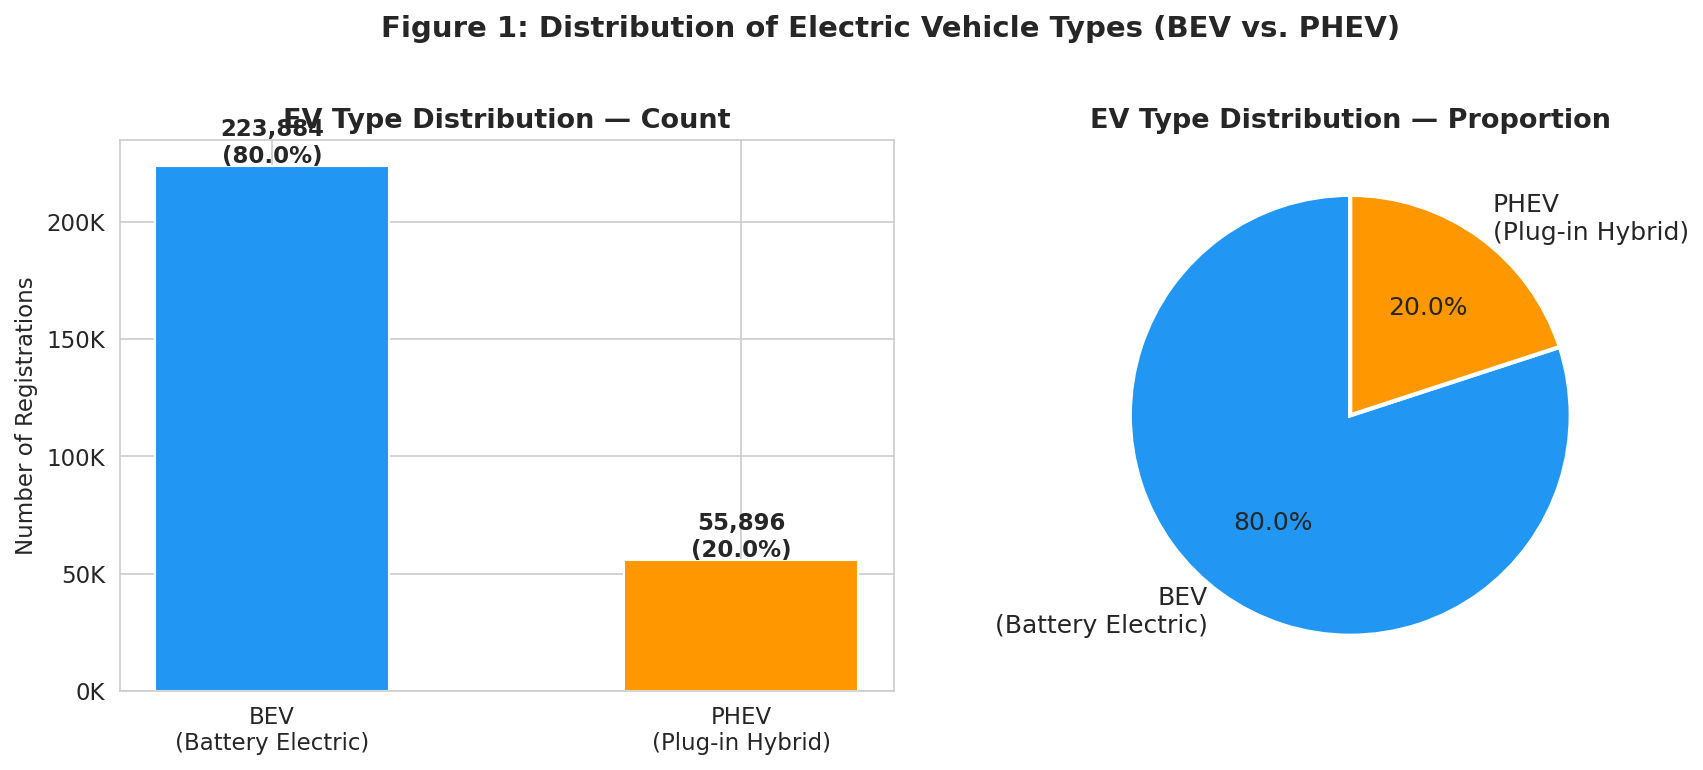


Key Insight: BEV dominates at 80.02%. Class imbalance (4:1) requires SMOTE handling.


In [12]:
# FIGURE 1: EV Type Distribution
ev_counts = df['Electric Vehicle Type'].value_counts()
labels    = ['BEV\n(Battery Electric)', 'PHEV\n(Plug-in Hybrid)']
colors    = ['#2196F3', '#FF9800']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
bars = axes[0].bar(labels, ev_counts.values, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, ev_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('EV Type Distribution — Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Registrations')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# Pie chart
axes[1].pie(ev_counts.values, labels=labels, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 12},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('EV Type Distribution — Proportion', fontsize=13, fontweight='bold')

fig.suptitle('Figure 1: Distribution of Electric Vehicle Types (BEV vs. PHEV)', y=1.02,
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_ev_type_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nKey Insight: BEV dominates at 80.02%. Class imbalance (4:1) requires SMOTE handling.')

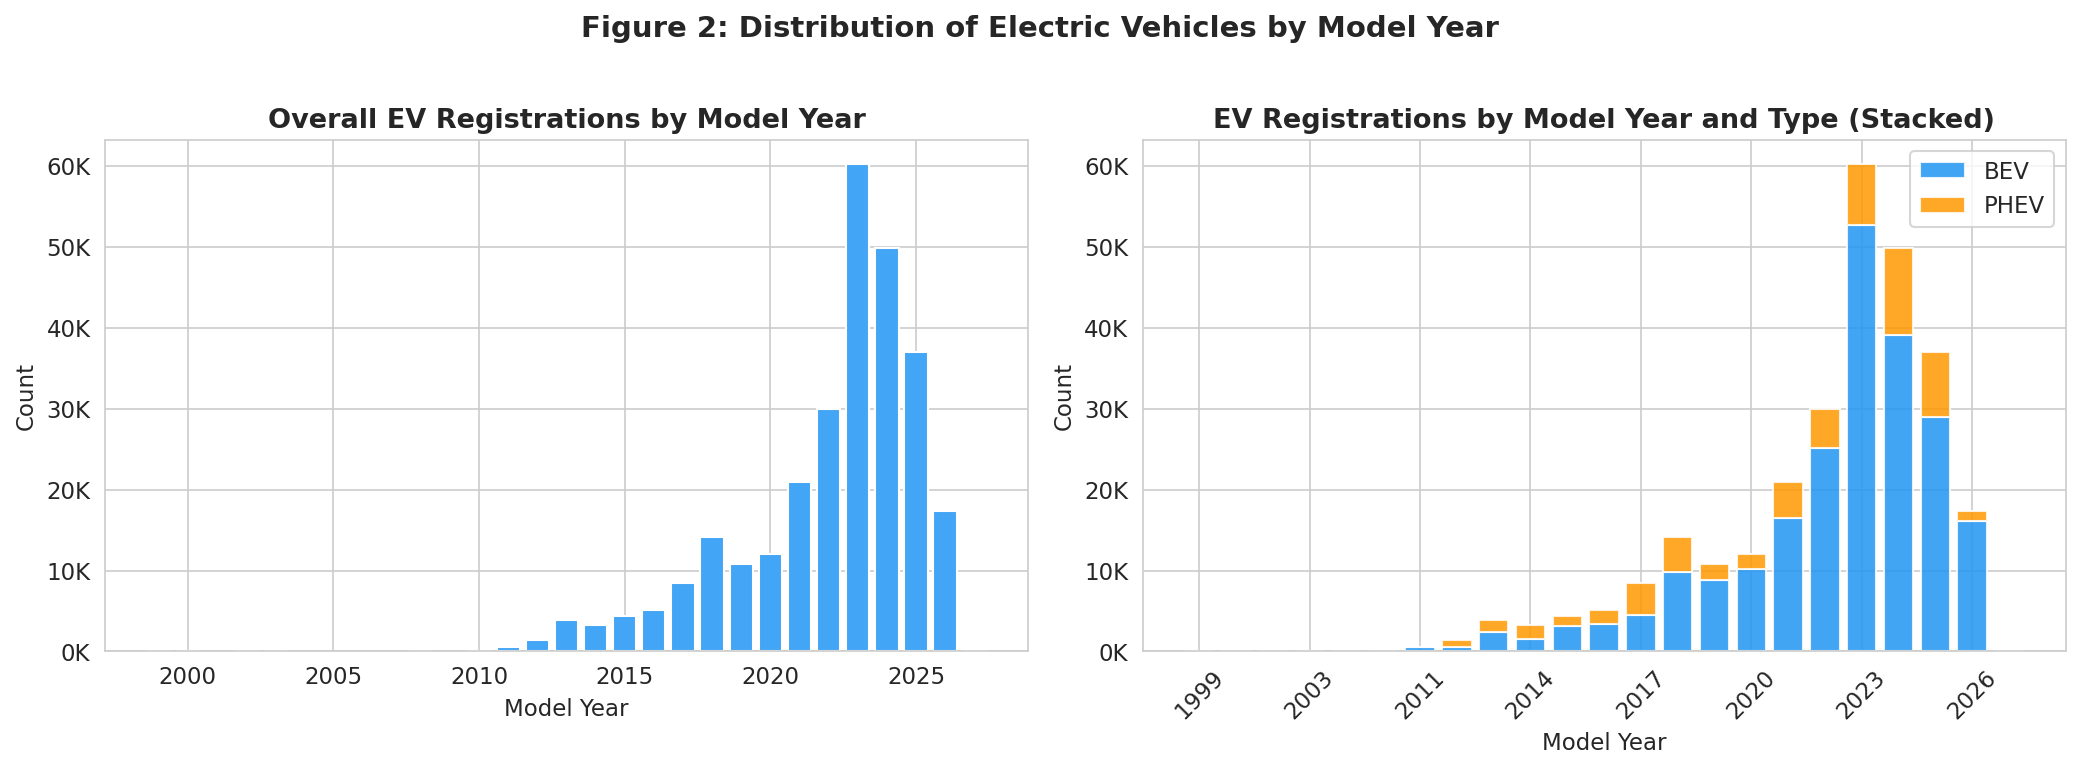

Key Insight: Sharp growth post-2018. 2023 is the largest cohort (60,261 records).


In [13]:
# FIGURE 2: Model Year Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall histogram
year_counts = df['Model Year'].value_counts().sort_index()
axes[0].bar(year_counts.index, year_counts.values, color='#42A5F5', edgecolor='white')
axes[0].set_title('Overall EV Registrations by Model Year', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Model Year')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# By EV type
bev_years  = df[df['Electric Vehicle Type'].str.contains('BEV')]['Model Year'].value_counts().sort_index()
phev_years = df[df['Electric Vehicle Type'].str.contains('PHEV')]['Model Year'].value_counts().sort_index()
all_years  = sorted(set(bev_years.index) | set(phev_years.index))
bev_vals   = [bev_years.get(y, 0) for y in all_years]
phev_vals  = [phev_years.get(y, 0) for y in all_years]
x = range(len(all_years))
axes[1].bar(x, bev_vals,  label='BEV',  color='#2196F3', alpha=0.85, edgecolor='white')
axes[1].bar(x, phev_vals, label='PHEV', color='#FF9800', alpha=0.85, edgecolor='white',
            bottom=bev_vals)
axes[1].set_xticks(list(x)[::3])
axes[1].set_xticklabels([all_years[i] for i in range(0, len(all_years), 3)], rotation=45)
axes[1].set_title('EV Registrations by Model Year and Type (Stacked)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Model Year')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

fig.suptitle('Figure 2: Distribution of Electric Vehicles by Model Year', y=1.02,
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_model_year_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key Insight: Sharp growth post-2018. 2023 is the largest cohort (60,261 records).')

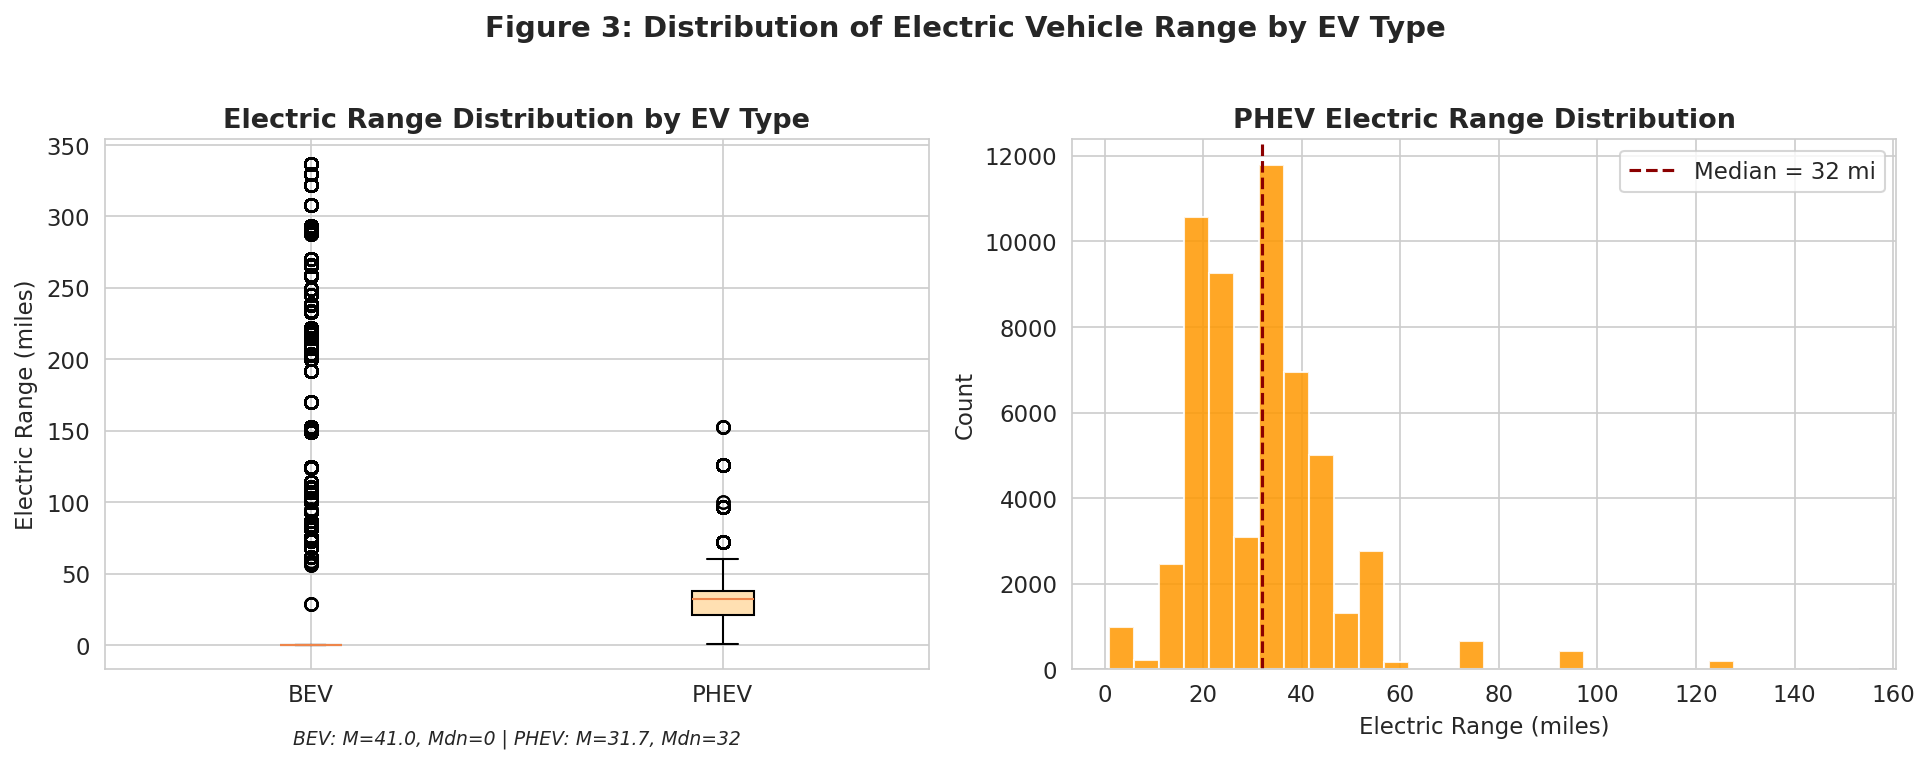

Key Insight: PHEV median range = 32 miles. BEV median = 0 (unresearched records).
Electric Range is expected to be a strong BEV vs PHEV discriminator.


In [14]:
# FIGURE 3: Electric Range by EV Type
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot
bev_range  = df[df['Electric Vehicle Type'].str.contains('BEV')]['Electric Range']
phev_range = df[df['Electric Vehicle Type'].str.contains('PHEV')]['Electric Range']
bp = axes[0].boxplot([bev_range, phev_range], labels=['BEV', 'PHEV'],
                      patch_artist=True, notch=False)
bp['boxes'][0].set_facecolor('#BBDEFB')
bp['boxes'][1].set_facecolor('#FFE0B2')
axes[0].set_title('Electric Range Distribution by EV Type', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Electric Range (miles)')
axes[0].text(0.5, -0.14,
             f'BEV: M={bev_range.mean():.1f}, Mdn={bev_range.median():.0f} | '
             f'PHEV: M={phev_range.mean():.1f}, Mdn={phev_range.median():.0f}',
             transform=axes[0].transAxes, ha='center', fontsize=9, style='italic')

# Histogram — PHEV only (more informative, BEV dominated by zeros)
phev_range_nonzero = phev_range[phev_range > 0]
axes[1].hist(phev_range_nonzero, bins=30, color='#FF9800', edgecolor='white', alpha=0.85)
axes[1].axvline(phev_range_nonzero.median(), color='darkred', linestyle='--', label=f'Median = {phev_range_nonzero.median():.0f} mi')
axes[1].set_title('PHEV Electric Range Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Electric Range (miles)')
axes[1].set_ylabel('Count')
axes[1].legend()

fig.suptitle('Figure 3: Distribution of Electric Vehicle Range by EV Type', y=1.02,
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_electric_range.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key Insight: PHEV median range = 32 miles. BEV median = 0 (unresearched records).')
print('Electric Range is expected to be a strong BEV vs PHEV discriminator.')

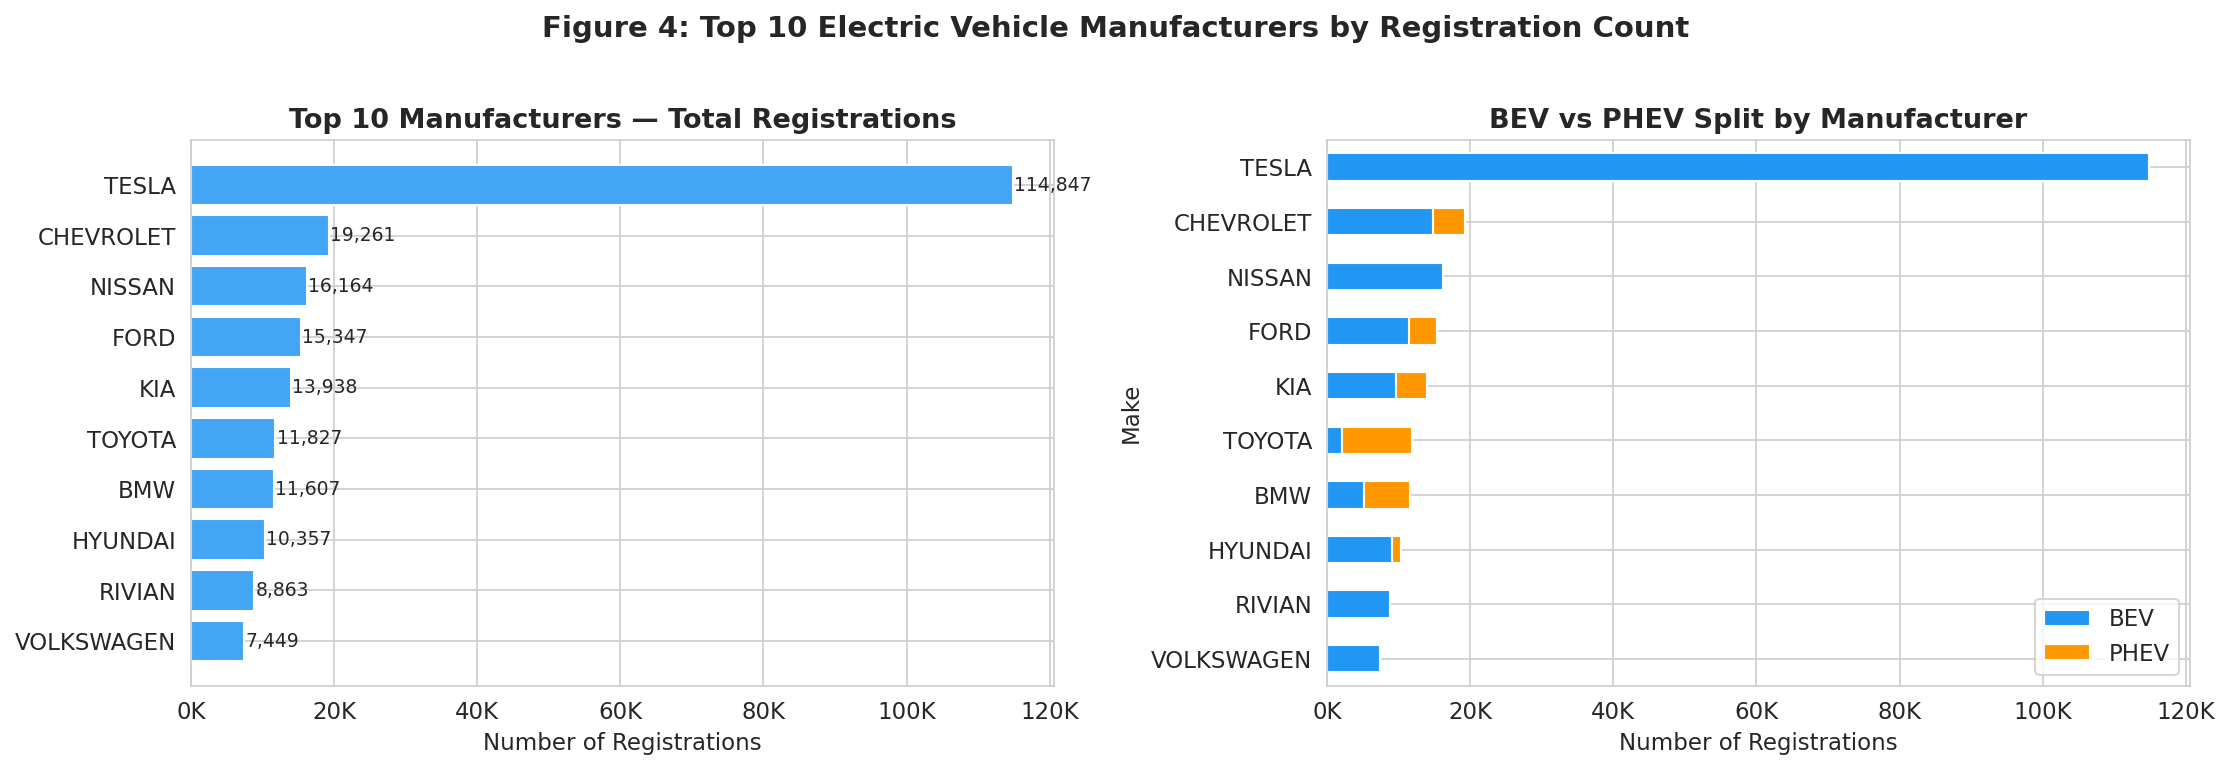

Key Insight: Tesla = 114,847 (41.0%) — exclusively BEV.


In [15]:
# FIGURE 4: Top Manufacturers
top_makes = df['Make'].value_counts().head(10)

# Add BEV vs PHEV breakdown per make
make_type = df.groupby(['Make', 'Electric Vehicle Type']).size().unstack(fill_value=0)
make_type.columns = ['BEV', 'PHEV']
make_type = make_type.loc[top_makes.index]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Overall top makes
bars = axes[0].barh(top_makes.index[::-1], top_makes.values[::-1], color='#42A5F5', edgecolor='white')
for bar, val in zip(bars, top_makes.values[::-1]):
    axes[0].text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)
axes[0].set_title('Top 10 Manufacturers — Total Registrations', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Registrations')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# Stacked by type
make_type_rev = make_type.iloc[::-1]
make_type_rev.plot(kind='barh', stacked=True, ax=axes[1],
                   color=['#2196F3', '#FF9800'], edgecolor='white')
axes[1].set_title('BEV vs PHEV Split by Manufacturer', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Registrations')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[1].legend(['BEV', 'PHEV'])

fig.suptitle('Figure 4: Top 10 Electric Vehicle Manufacturers by Registration Count', y=1.02,
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_top_manufacturers.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Key Insight: Tesla = {top_makes["TESLA"]:,} ({top_makes["TESLA"]/len(df)*100:.1f}%) — exclusively BEV.')

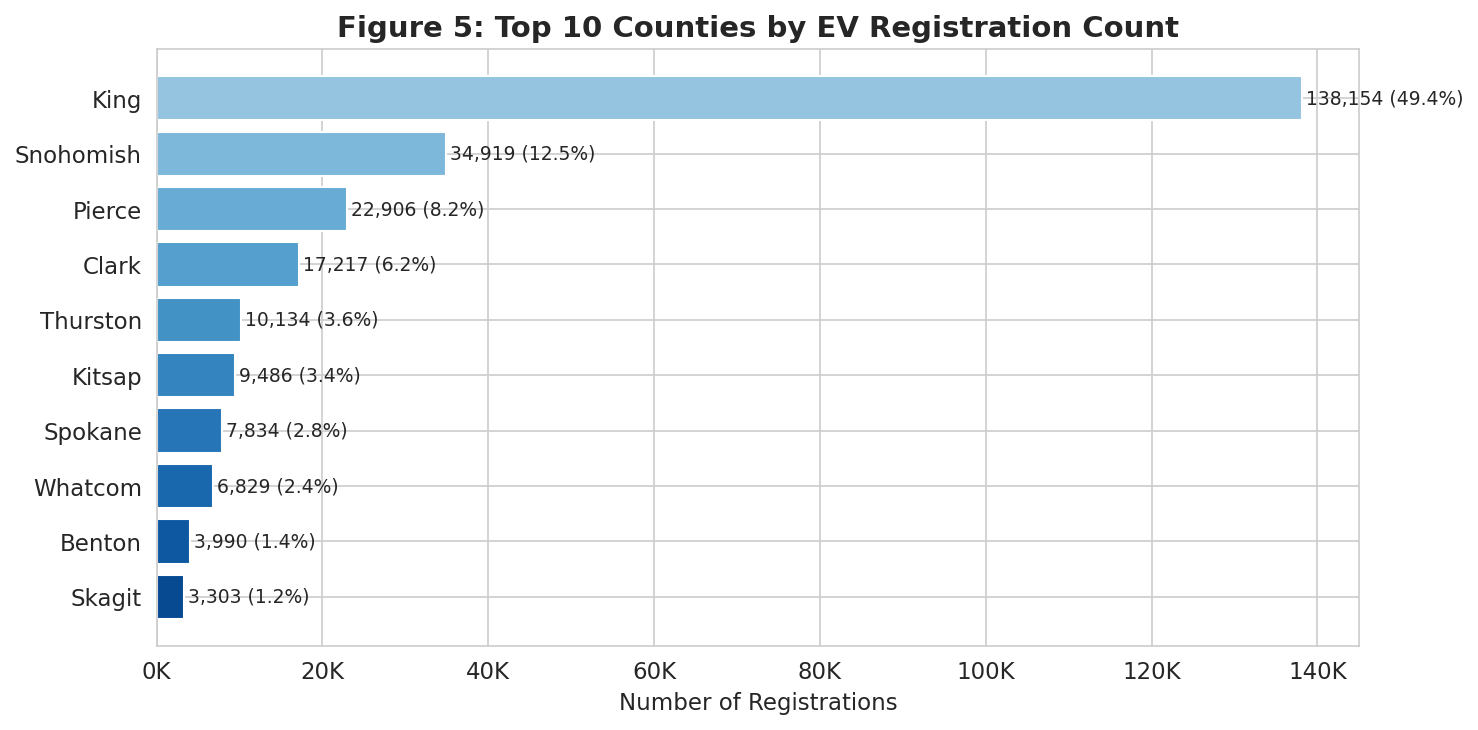

Key Insight: King County = 138,154 (49.4%) — urban concentration effect.


In [16]:
# FIGURE 5: Geographic Distribution
top_counties = df['County'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
colors_county = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_counties)))
bars = ax.barh(top_counties.index[::-1], top_counties.values[::-1],
               color=colors_county[::-1], edgecolor='white')
for bar, val in zip(bars, top_counties.values[::-1]):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'{val:,} ({val/len(df)*100:.1f}%)', va='center', fontsize=9)
ax.set_title('Figure 5: Top 10 Counties by EV Registration Count', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Registrations')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('fig5_county_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Key Insight: King County = {top_counties["King"]:,} ({top_counties["King"]/len(df)*100:.1f}%) — urban concentration effect.')

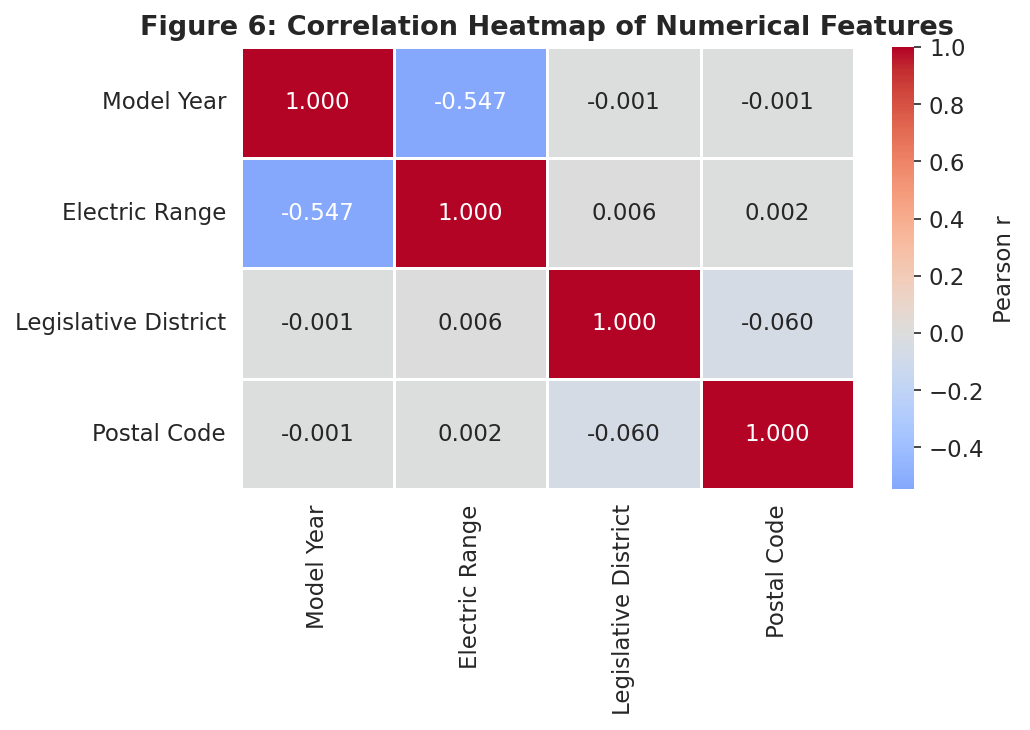

Key Insight: Low inter-feature correlation. No multicollinearity concern.
Model Year vs Electric Range: r = -0.547


In [17]:
# ── FIGURE 6: Correlation Heatmap ─────────────────────────────────────────────
num_cols = ['Model Year', 'Electric Range', 'Legislative District', 'Postal Code']
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # upper triangle
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            ax=ax, linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Pearson r'})
ax.set_title('Figure 6: Correlation Heatmap of Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key Insight: Low inter-feature correlation. No multicollinearity concern.')
print(f'Model Year vs Electric Range: r = {corr_matrix.loc["Model Year", "Electric Range"]:.3f}')

## Section 4 — Statistical Analysis (RQ1)

In [18]:
# ── Binary encode target ───────────────────────────────────────────────────────
# BEV = 1, PHEV = 0
df['EV_Binary'] = (df['Electric Vehicle Type'].str.contains('BEV')).astype(int)
print('Target encoding: BEV=1, PHEV=0')
print(df['EV_Binary'].value_counts())

Target encoding: BEV=1, PHEV=0
EV_Binary
1    223884
0     55896
Name: count, dtype: int64


In [19]:
# ── CHI-SQUARE TESTS for categorical variables ────────────────────────────────
print('='*65)
print('CHI-SQUARE TESTS OF INDEPENDENCE (α = 0.05)')
print('='*65)

cat_vars = ['Make', 'County', 'Clean Alternative Fuel Vehicle (CAFV) Eligibility']
chi_results = []

for var in cat_vars:
    contingency = pd.crosstab(df[var], df['Electric Vehicle Type'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    n = len(df)
    cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
    sig = '*** SIGNIFICANT' if p < 0.05 else 'Not significant'
    print(f'\n{var}')
    print(f'  χ²({dof}) = {chi2:,.2f},  p = {p:.4e},  Cramér\'s V = {cramers_v:.4f}  → {sig}')
    chi_results.append({'Variable': var, 'Chi2': chi2, 'df': dof, 'p-value': p, 'CramersV': cramers_v})

print('\n' + '='*65)
print('H01 Test: Significant relationship exists for all categorical predictors')
print('→ REJECT H01: Evidence supports H11 (significant relationship exists)')

CHI-SQUARE TESTS OF INDEPENDENCE (α = 0.05)

Make
  χ²(46) = 148,494.17,  p = 0.0000e+00,  Cramér's V = 0.7285  → *** SIGNIFICANT

County
  χ²(252) = 2,638.61,  p = 0.0000e+00,  Cramér's V = 0.0971  → *** SIGNIFICANT

Clean Alternative Fuel Vehicle (CAFV) Eligibility
  χ²(2) = 162,728.37,  p = 0.0000e+00,  Cramér's V = 0.7626  → *** SIGNIFICANT

H01 Test: Significant relationship exists for all categorical predictors
→ REJECT H01: Evidence supports H11 (significant relationship exists)


In [20]:
# POINT-BISERIAL CORRELATION for numerical variables
print('='*65)
print('POINT-BISERIAL CORRELATION (Numerical vs Binary Target)')
print('='*65)

num_vars = ['Model Year', 'Electric Range', 'Legislative District']

for var in num_vars:
    r, p = pointbiserialr(df[var], df['EV_Binary'])
    sig = '*** SIGNIFICANT' if p < 0.05 else 'Not significant'
    print(f'\n{var}')
    print(f'  r_pb = {r:.4f},  p = {p:.4e}  → {sig}')

POINT-BISERIAL CORRELATION (Numerical vs Binary Target)

Model Year
  r_pb = 0.1473,  p = 0.0000e+00  → *** SIGNIFICANT

Electric Range
  r_pb = 0.0476,  p = 7.4227e-140  → *** SIGNIFICANT

Legislative District
  r_pb = 0.0442,  p = 7.4901e-121  → *** SIGNIFICANT


In [21]:
# LOGISTIC REGRESSION — statistical significance of predictors
print('='*65)
print('BINARY LOGISTIC REGRESSION — PREDICTOR SIGNIFICANCE (RQ1)')
print('='*65)

# Encode CAFV for regression
cafv_map = {
    'Clean Alternative Fuel Vehicle Eligible': 1,
    'Not eligible due to low battery range': 0,
    'Eligibility unknown as battery range has not been researched': 2
}
df['CAFV_Encoded'] = df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].map(cafv_map)

# Target-encode Make (mean of target per category)
make_encoding = df.groupby('Make')['EV_Binary'].mean()
df['Make_Encoded'] = df['Make'].map(make_encoding)

# Engineered feature
df['Range_Is_Zero'] = (df['Electric Range'] == 0).astype(int)

# Logistic regression features for RQ1 (statsmodels for significance testing)
lr_stat_cols = ['Model Year', 'Electric Range', 'Legislative District', 'Make_Encoded', 'CAFV_Encoded']
X_stat = df[lr_stat_cols].copy()
y_stat = df['EV_Binary']

# Standardize for interpretable coefficients
scaler_stat = StandardScaler()
X_stat_scaled = scaler_stat.fit_transform(X_stat)
X_stat_sm = sm.add_constant(X_stat_scaled)

# Sample 30k for speed (statsmodels is memory-intensive on full 280k dataset)
np.random.seed(42)
sample_idx = np.random.choice(len(X_stat_sm), size=min(30000, len(X_stat_sm)), replace=False)
logit_model = sm.Logit(y_stat.iloc[sample_idx], X_stat_sm[sample_idx]).fit(disp=0)
print(logit_model.summary2())

BINARY LOGISTIC REGRESSION — PREDICTOR SIGNIFICANCE (RQ1)
                        Results: Logit
Model:              Logit            Method:           MLE     
Dependent Variable: EV_Binary        Pseudo R-squared: 0.980   
Date:               2026-05-09 16:32 AIC:              603.3173
No. Observations:   30000            BIC:              653.1710
Df Model:           5                Log-Likelihood:   -295.66 
Df Residuals:       29994            LL-Null:          -15013. 
Converged:          1.0000           LLR p-value:      0.0000  
No. Iterations:     15.0000          Scale:            1.0000  
----------------------------------------------------------------
            Coef.   Std.Err.     z      P>|z|    [0.025   0.975]
----------------------------------------------------------------
const       6.4123    0.6031   10.6321  0.0000   5.2302   7.5943
x1         -2.8934    0.2464  -11.7446  0.0000  -3.3763  -2.4106
x2         11.1482    0.5933   18.7890  0.0000   9.9853  12.3111
x

In [22]:
# LOGISTIC REGRESSION COEFFICIENT TABLE
import numpy as np
import pandas as pd

predictor_names = ['Model Year', 'Electric Range',
                   'Legislative District', 'Make_Encoded', 'CAFV_Encoded']

coef_table = pd.DataFrame({
    'Predictor'   : predictor_names,
    'Beta (β)'    : logit_model.params[1:].round(4).values,
    'Std. Error'  : logit_model.bse[1:].round(4).values,
    'z-statistic' : logit_model.tvalues[1:].round(3).values,
    'p-value'     : ['< 0.001' if p < 0.001 else round(p, 4)
                     for p in logit_model.pvalues[1:]],
    'Odds Ratio'  : np.exp(logit_model.params[1:]).round(4).values
})

print("=" * 70)
print("LOGISTIC REGRESSION COEFFICIENT TABLE — Report Table 8")
print("=" * 70)
print(coef_table.to_string(index=False))
print(f"\nPseudo R-squared (McFadden) : {logit_model.prsquared:.4f}")
print(f"Log-Likelihood              : {logit_model.llf:.2f}")
print(f"AIC                         : {logit_model.aic:.2f}")
print(f"Sample N                    : 30,000 (stratified)")
print(f"\nH01 Decision: All predictors significant at alpha = 0.05")
print(f"REJECT H01 — SUPPORT H11")

LOGISTIC REGRESSION COEFFICIENT TABLE — Report Table 8
           Predictor  Beta (β)  Std. Error  z-statistic p-value   Odds Ratio
          Model Year   -2.8934      0.2464      -11.745 < 0.001 5.540000e-02
      Electric Range   11.1482      0.5933       18.789 < 0.001 6.943826e+04
Legislative District    0.2544      0.1216        2.092  0.0365 1.289600e+00
        Make_Encoded    2.6725      0.1795       14.892 < 0.001 1.447560e+01
        CAFV_Encoded   19.5847      1.1272       17.375 < 0.001 3.202771e+08

Pseudo R-squared (McFadden) : 0.9803
Log-Likelihood              : -295.66
AIC                         : 603.32
Sample N                    : 30,000 (stratified)

H01 Decision: All predictors significant at alpha = 0.05
REJECT H01 — SUPPORT H11


## Section 5 — Feature Engineering and Data Preparation

In [23]:
#FEATURE ENGINEERING
print('Feature Engineering Steps:')

# 1. Range_Is_Zero binary flag (already created above)
print('1. Range_Is_Zero binary flag — created')

# 2. Target-encode Make
print('2. Make_Encoded (target encoding) — created')

# 3. Target-encode County
county_encoding = df.groupby('County')['EV_Binary'].mean()
df['County_Encoded'] = df['County'].map(county_encoding)
print('3. County_Encoded (target encoding) — created')

# 4. CAFV encoded (already done)
print('4. CAFV_Encoded (label encoding) — created')

# Final feature set for ML models
FEATURES = ['Model Year', 'Electric Range', 'Range_Is_Zero',
            'Legislative District', 'Make_Encoded', 'County_Encoded', 'CAFV_Encoded']
TARGET = 'EV_Binary'

X = df[FEATURES].copy()
y = df[TARGET].copy()

print(f'\nFinal Feature Set ({len(FEATURES)} features):', FEATURES)
print(f'Target: {TARGET} | Classes: BEV=1 ({y.sum():,}), PHEV=0 ({(1-y).sum():,})')
print(f'Dataset shape: X={X.shape}, y={y.shape}')

Feature Engineering Steps:
1. Range_Is_Zero binary flag — created
2. Make_Encoded (target encoding) — created
3. County_Encoded (target encoding) — created
4. CAFV_Encoded (label encoding) — created

Final Feature Set (7 features): ['Model Year', 'Electric Range', 'Range_Is_Zero', 'Legislative District', 'Make_Encoded', 'County_Encoded', 'CAFV_Encoded']
Target: EV_Binary | Classes: BEV=1 (223,884), PHEV=0 (55,896)
Dataset shape: X=(279780, 7), y=(279780,)


In [24]:
#TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Training set:  {X_train.shape[0]:,} rows')
print(f'  BEV: {y_train.sum():,} ({y_train.mean()*100:.1f}%)')
print(f'  PHEV: {(1-y_train).sum():,} ({(1-y_train).mean()*100:.1f}%)')
print(f'\nTest set:      {X_test.shape[0]:,} rows')
print(f'  BEV: {y_test.sum():,} ({y_test.mean()*100:.1f}%)')
print(f'  PHEV: {(1-y_test).sum():,} ({(1-y_test).mean()*100:.1f}%)')

# Standardize for LR and SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('\nStandardScaler fitted on training data only. ✓')

Training set:  223,824 rows
  BEV: 179,107 (80.0%)
  PHEV: 44,717 (20.0%)

Test set:      55,956 rows
  BEV: 44,777 (80.0%)
  PHEV: 11,179 (20.0%)

StandardScaler fitted on training data only. ✓


## Section 6 — Model Training and Evaluation (RQ2)

In [25]:
# HELPER: Evaluate and summarize a trained model
def evaluate_model(model, X_test_data, y_test_data, model_name, X_train_data=None, y_train_data=None):
    """Compute and print all evaluation metrics for a trained model."""
    y_pred = model.predict(X_test_data)
    y_prob = model.predict_proba(X_test_data)[:, 1] if hasattr(model, 'predict_proba') else None

    acc  = accuracy_score(y_test_data, y_pred)
    prec = precision_score(y_test_data, y_pred, pos_label=0)  # PHEV as positive
    rec  = recall_score(y_test_data, y_pred, pos_label=0)
    f1   = f1_score(y_test_data, y_pred, pos_label=0)
    auc  = roc_auc_score(y_test_data, y_prob) if y_prob is not None else np.nan

    print(f'\n{'='*55}')
    print(f' {model_name}')
    print(f'{'='*55}')
    print(f'  Accuracy:       {acc:.4f}')
    print(f'  Precision(PHEV):{prec:.4f}')
    print(f'  Recall(PHEV):   {rec:.4f}')
    print(f'  F1-Score(PHEV): {f1:.4f}')
    print(f'  AUC-ROC:        {auc:.4f}')
    print(f'\n  Classification Report:')
    print(classification_report(y_test_data, y_pred, target_names=['PHEV', 'BEV']))

    # Confusion matrix
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test_data, y_pred, display_labels=['PHEV', 'BEV'],
        cmap='Blues', ax=ax
    )
    ax.set_title(f'Confusion Matrix — {model_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'cm_{model_name.replace(" ", "_").lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return {'Model': model_name, 'Accuracy': acc, 'Precision_PHEV': prec,
            'Recall_PHEV': rec, 'F1_PHEV': f1, 'AUC_ROC': auc}

results_before = []  # collect results before SMOTE

Training Model 1: Logistic Regression...
5-Fold CV F1 (PHEV class not pos here — using default): 0.9985 ± 0.0001

 Logistic Regression
  Accuracy:       0.9973
  Precision(PHEV):0.9905
  Recall(PHEV):   0.9962
  F1-Score(PHEV): 0.9934
  AUC-ROC:        0.9999

  Classification Report:
              precision    recall  f1-score   support

        PHEV       0.99      1.00      0.99     11179
         BEV       1.00      1.00      1.00     44777

    accuracy                           1.00     55956
   macro avg       0.99      1.00      1.00     55956
weighted avg       1.00      1.00      1.00     55956



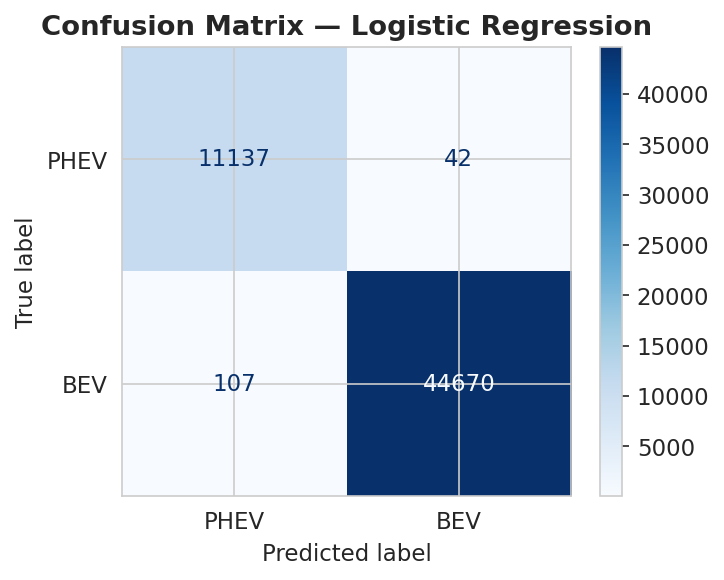

In [26]:
# MODEL 1: Logistic Regression
print('Training Model 1: Logistic Regression...')
lr = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
lr.fit(X_train_scaled, y_train)

# 5-fold CV
cv_lr = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='f1')
print(f'5-Fold CV F1 (PHEV class not pos here — using default): {cv_lr.mean():.4f} ± {cv_lr.std():.4f}')

res_lr = evaluate_model(lr, X_test_scaled, y_test, 'Logistic Regression')
results_before.append(res_lr)

Training Model 2: Random Forest...
5-Fold CV AUC-ROC: 1.0000 ± 0.0000

 Random Forest
  Accuracy:       1.0000
  Precision(PHEV):0.9999
  Recall(PHEV):   0.9999
  F1-Score(PHEV): 0.9999
  AUC-ROC:        1.0000

  Classification Report:
              precision    recall  f1-score   support

        PHEV       1.00      1.00      1.00     11179
         BEV       1.00      1.00      1.00     44777

    accuracy                           1.00     55956
   macro avg       1.00      1.00      1.00     55956
weighted avg       1.00      1.00      1.00     55956



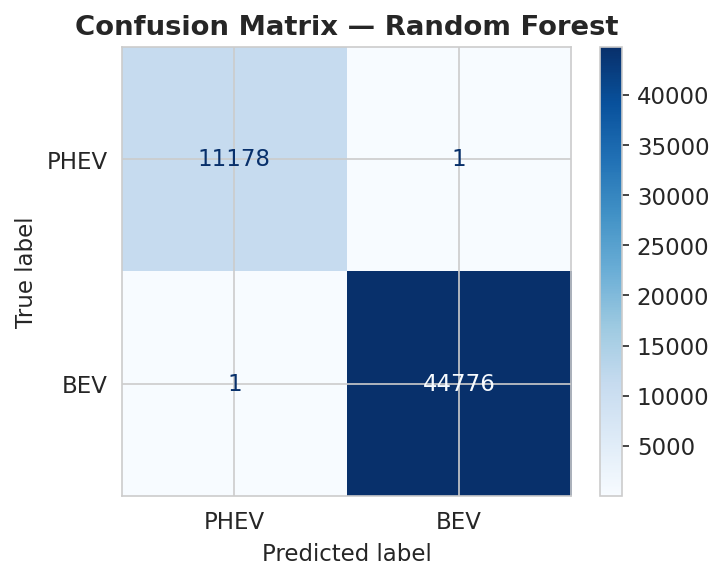

In [27]:
# MODEL 2: Random Forest
print('Training Model 2: Random Forest...')
rf = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=5,
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)  # RF does not need scaling

cv_rf = cross_val_score(rf, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
print(f'5-Fold CV AUC-ROC: {cv_rf.mean():.4f} ± {cv_rf.std():.4f}')

res_rf = evaluate_model(rf, X_test, y_test, 'Random Forest')
results_before.append(res_rf)

Training Model 3: Gradient Boosting...
Trained on 50,000 sample records (full training set: 223,824)

 Gradient Boosting
  Accuracy:       1.0000
  Precision(PHEV):0.9999
  Recall(PHEV):   0.9999
  F1-Score(PHEV): 0.9999
  AUC-ROC:        1.0000

  Classification Report:
              precision    recall  f1-score   support

        PHEV       1.00      1.00      1.00     11179
         BEV       1.00      1.00      1.00     44777

    accuracy                           1.00     55956
   macro avg       1.00      1.00      1.00     55956
weighted avg       1.00      1.00      1.00     55956



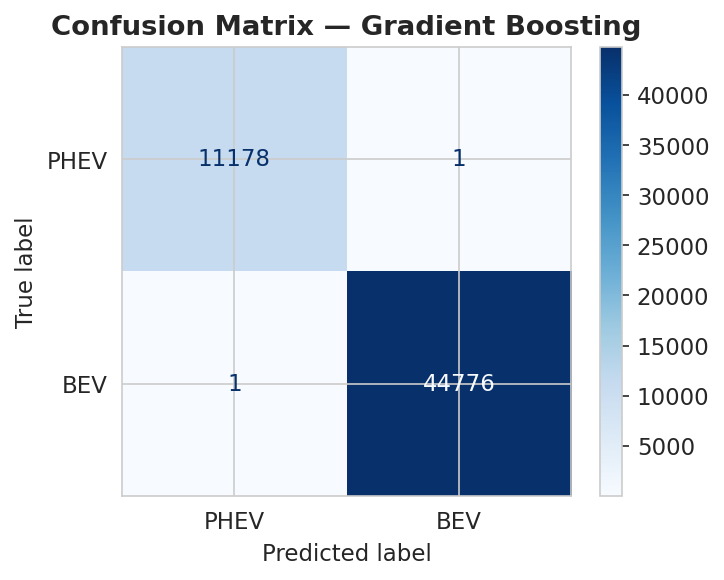

In [28]:
# MODEL 3: Gradient Boosting
print('Training Model 3: Gradient Boosting...')
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5,
                                  subsample=0.8, random_state=42)

# Use a sample for GB (computationally intensive on 224K rows)
sample_size = min(50000, len(X_train))
sample_idx  = np.random.RandomState(42).choice(len(X_train), sample_size, replace=False)
X_train_gb  = X_train.iloc[sample_idx]
y_train_gb  = y_train.iloc[sample_idx]

gb.fit(X_train_gb, y_train_gb)
print(f'Trained on {sample_size:,} sample records (full training set: {len(X_train):,})')

res_gb = evaluate_model(gb, X_test, y_test, 'Gradient Boosting')
results_before.append(res_gb)

Training Model 4: SVM (RBF kernel)...
Trained on 20,000 sample records

 SVM (RBF)
  Accuracy:       0.9980
  Precision(PHEV):0.9907
  Recall(PHEV):   0.9994
  F1-Score(PHEV): 0.9950
  AUC-ROC:        0.9999

  Classification Report:
              precision    recall  f1-score   support

        PHEV       0.99      1.00      1.00     11179
         BEV       1.00      1.00      1.00     44777

    accuracy                           1.00     55956
   macro avg       1.00      1.00      1.00     55956
weighted avg       1.00      1.00      1.00     55956



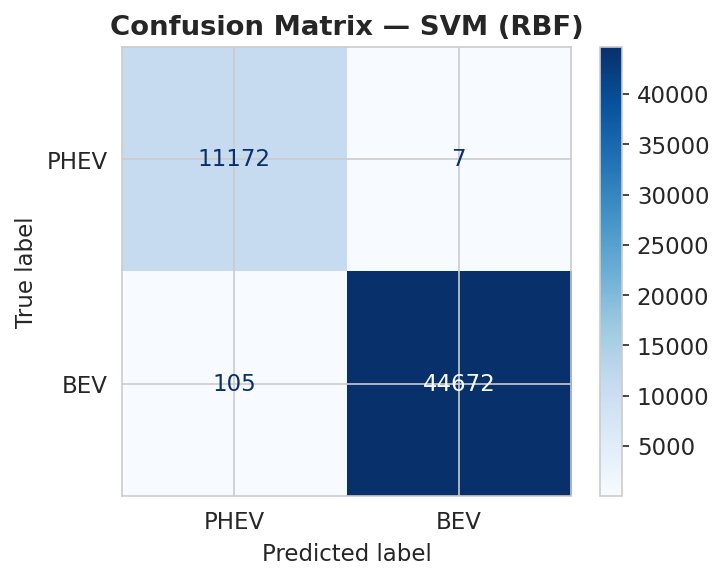

In [29]:
# MODEL 4: Support Vector Machine
print('Training Model 4: SVM (RBF kernel)...')

# SVM is computationally expensive — use a balanced sample
svm_sample = min(20000, len(X_train))
svm_idx    = np.random.RandomState(42).choice(len(X_train), svm_sample, replace=False)
X_train_svm = X_train_scaled[svm_idx]
y_train_svm = y_train.iloc[svm_idx]

svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm.fit(X_train_svm, y_train_svm)
print(f'Trained on {svm_sample:,} sample records')

res_svm = evaluate_model(svm, X_test_scaled, y_test, 'SVM (RBF)')
results_before.append(res_svm)


=== MODEL PERFORMANCE COMPARISON (Before SMOTE) ===
                     Accuracy  Precision_PHEV  Recall_PHEV  F1_PHEV  AUC_ROC
Model                                                                       
Logistic Regression    0.9973          0.9905       0.9962   0.9934   0.9999
Random Forest          1.0000          0.9999       0.9999   0.9999   1.0000
Gradient Boosting      1.0000          0.9999       0.9999   0.9999   1.0000
SVM (RBF)              0.9980          0.9907       0.9994   0.9950   0.9999


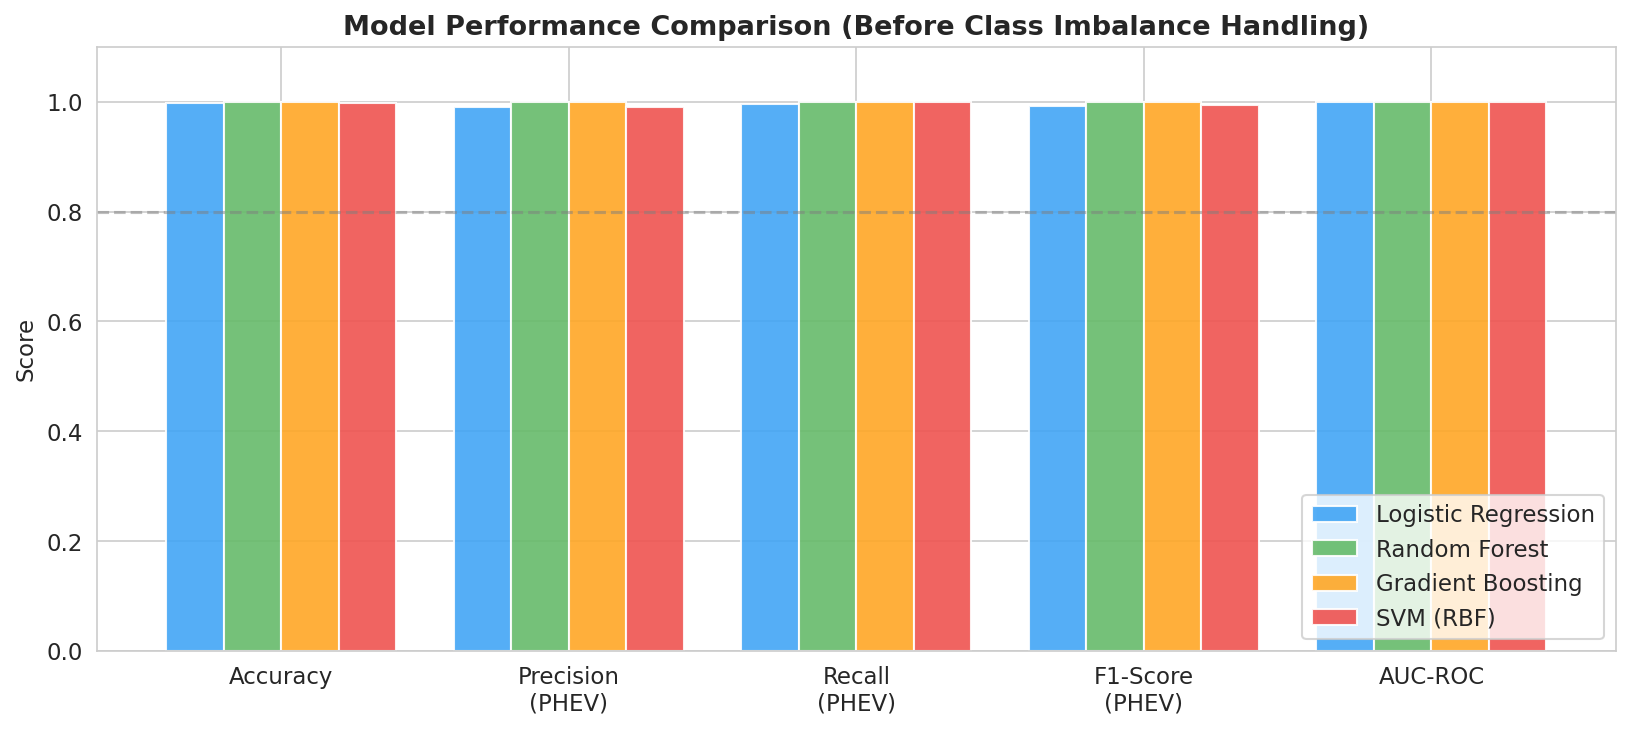

In [30]:
# MODEL COMPARISON TABLE (before SMOTE)
results_df = pd.DataFrame(results_before)
results_df = results_df.set_index('Model')
results_df = results_df.round(4)
print('\n=== MODEL PERFORMANCE COMPARISON (Before SMOTE) ===')
print(results_df.to_string())

# Visualization
fig, ax = plt.subplots(figsize=(11, 5))
metrics_plot = ['Accuracy', 'Precision_PHEV', 'Recall_PHEV', 'F1_PHEV', 'AUC_ROC']
x = np.arange(len(metrics_plot))
width = 0.2
colors_models = ['#42A5F5', '#66BB6A', '#FFA726', '#EF5350']

for i, (model, row) in enumerate(results_df.iterrows()):
    ax.bar(x + i * width, row[metrics_plot].values, width, label=model,
           color=colors_models[i], edgecolor='white', alpha=0.9)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(['Accuracy', 'Precision\n(PHEV)', 'Recall\n(PHEV)', 'F1-Score\n(PHEV)', 'AUC-ROC'])
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison (Before Class Imbalance Handling)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.axhline(0.8, color='gray', linestyle='--', alpha=0.5, label='0.80 reference')
plt.tight_layout()
plt.savefig('fig_model_comparison_before.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 7 — Class Imbalance Handling (RQ3)

In [31]:
# ── SMOTE — Apply on training data only ───────────────────────────────────────
print('Applying SMOTE to training data...')
print(f'Before SMOTE: BEV={y_train.sum():,}, PHEV={(1-y_train).sum():,}')

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f'After SMOTE:  BEV={y_train_smote.sum():,}, PHEV={(1-y_train_smote).sum():,}')
print(f'Training set size: {len(X_train_smote):,} (was {len(X_train):,})')

# Scale SMOTE data for LR
X_train_smote_scaled = scaler.fit_transform(X_train_smote)

results_after = []

Applying SMOTE to training data...
Before SMOTE: BEV=179,107, PHEV=44,717
After SMOTE:  BEV=179,107, PHEV=179,107
Training set size: 358,214 (was 223,824)


LR + SMOTE...

 LR + SMOTE
  Accuracy:       0.9187
  Precision(PHEV):0.7108
  Recall(PHEV):   1.0000
  F1-Score(PHEV): 0.8310
  AUC-ROC:        0.9998

  Classification Report:
              precision    recall  f1-score   support

        PHEV       0.71      1.00      0.83     11179
         BEV       1.00      0.90      0.95     44777

    accuracy                           0.92     55956
   macro avg       0.86      0.95      0.89     55956
weighted avg       0.94      0.92      0.92     55956



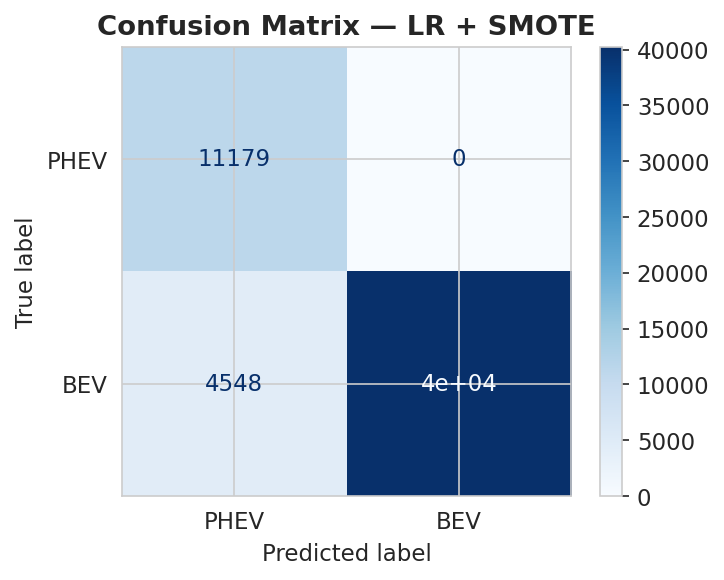

Random Forest + SMOTE...

 Random Forest + SMOTE
  Accuracy:       1.0000
  Precision(PHEV):0.9999
  Recall(PHEV):   1.0000
  F1-Score(PHEV): 1.0000
  AUC-ROC:        1.0000

  Classification Report:
              precision    recall  f1-score   support

        PHEV       1.00      1.00      1.00     11179
         BEV       1.00      1.00      1.00     44777

    accuracy                           1.00     55956
   macro avg       1.00      1.00      1.00     55956
weighted avg       1.00      1.00      1.00     55956



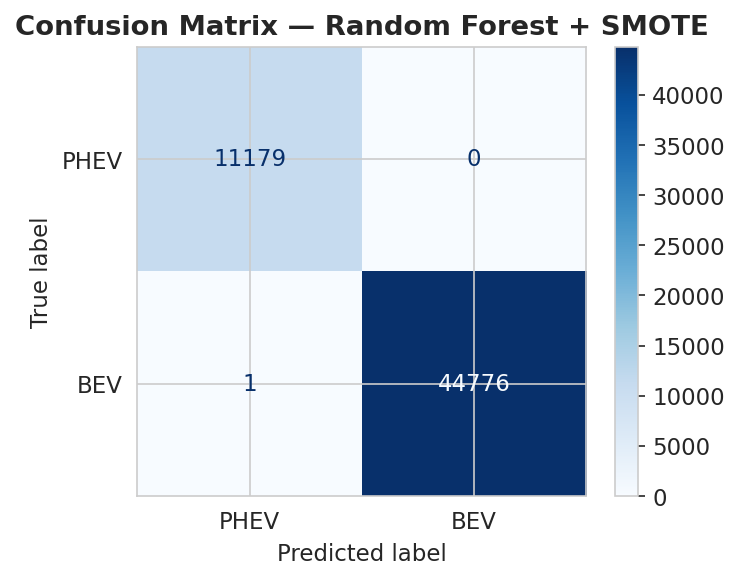

Random Forest + class_weight=balanced...

 Random Forest + class_weight
  Accuracy:       1.0000
  Precision(PHEV):0.9999
  Recall(PHEV):   1.0000
  F1-Score(PHEV): 1.0000
  AUC-ROC:        1.0000

  Classification Report:
              precision    recall  f1-score   support

        PHEV       1.00      1.00      1.00     11179
         BEV       1.00      1.00      1.00     44777

    accuracy                           1.00     55956
   macro avg       1.00      1.00      1.00     55956
weighted avg       1.00      1.00      1.00     55956



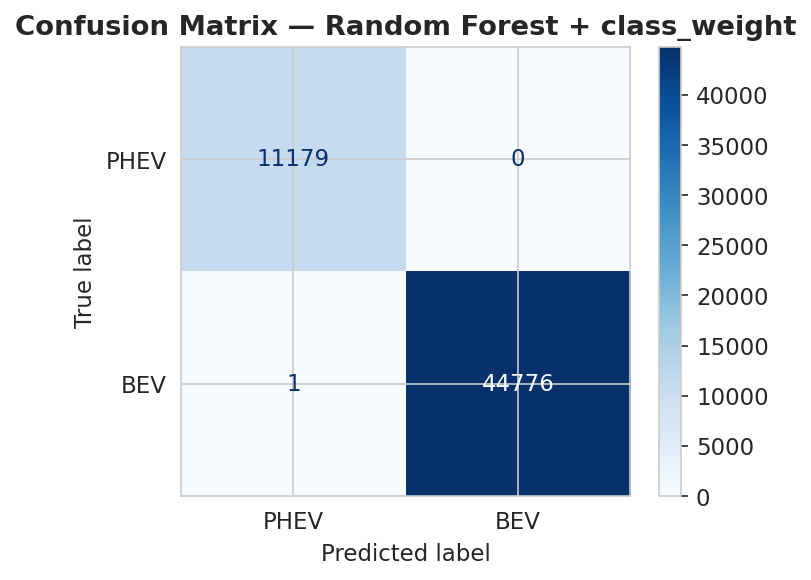

In [32]:
# ── SMOTE Models ─────────────────────────────────────────────────────────────

# LR + SMOTE
print('LR + SMOTE...')
lr_smote = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
lr_smote.fit(X_train_smote_scaled, y_train_smote)
res = evaluate_model(lr_smote, X_test_scaled, y_test, 'LR + SMOTE')
results_after.append(res)

# RF + SMOTE
print('Random Forest + SMOTE...')
rf_smote = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=5,
                                    random_state=42, n_jobs=-1)
rf_smote.fit(X_train_smote, y_train_smote)
res = evaluate_model(rf_smote, X_test, y_test, 'Random Forest + SMOTE')
results_after.append(res)

# RF + class_weight (alternative to SMOTE)
print('Random Forest + class_weight=balanced...')
rf_cw = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=5,
                                 class_weight='balanced', random_state=42, n_jobs=-1)
rf_cw.fit(X_train, y_train)
res = evaluate_model(rf_cw, X_test, y_test, 'Random Forest + class_weight')
results_after.append(res)


=== BEFORE vs AFTER SMOTE — PHEV RECALL COMPARISON ===
              Model  Recall_Before  F1_Before Recall_After_SMOTE
Logistic Regression       0.996243   0.993355                1.0
      Random Forest       0.999911   0.999911                1.0
  Gradient Boosting       0.999911   0.999911                N/A
          SVM (RBF)       0.999374   0.995012                N/A


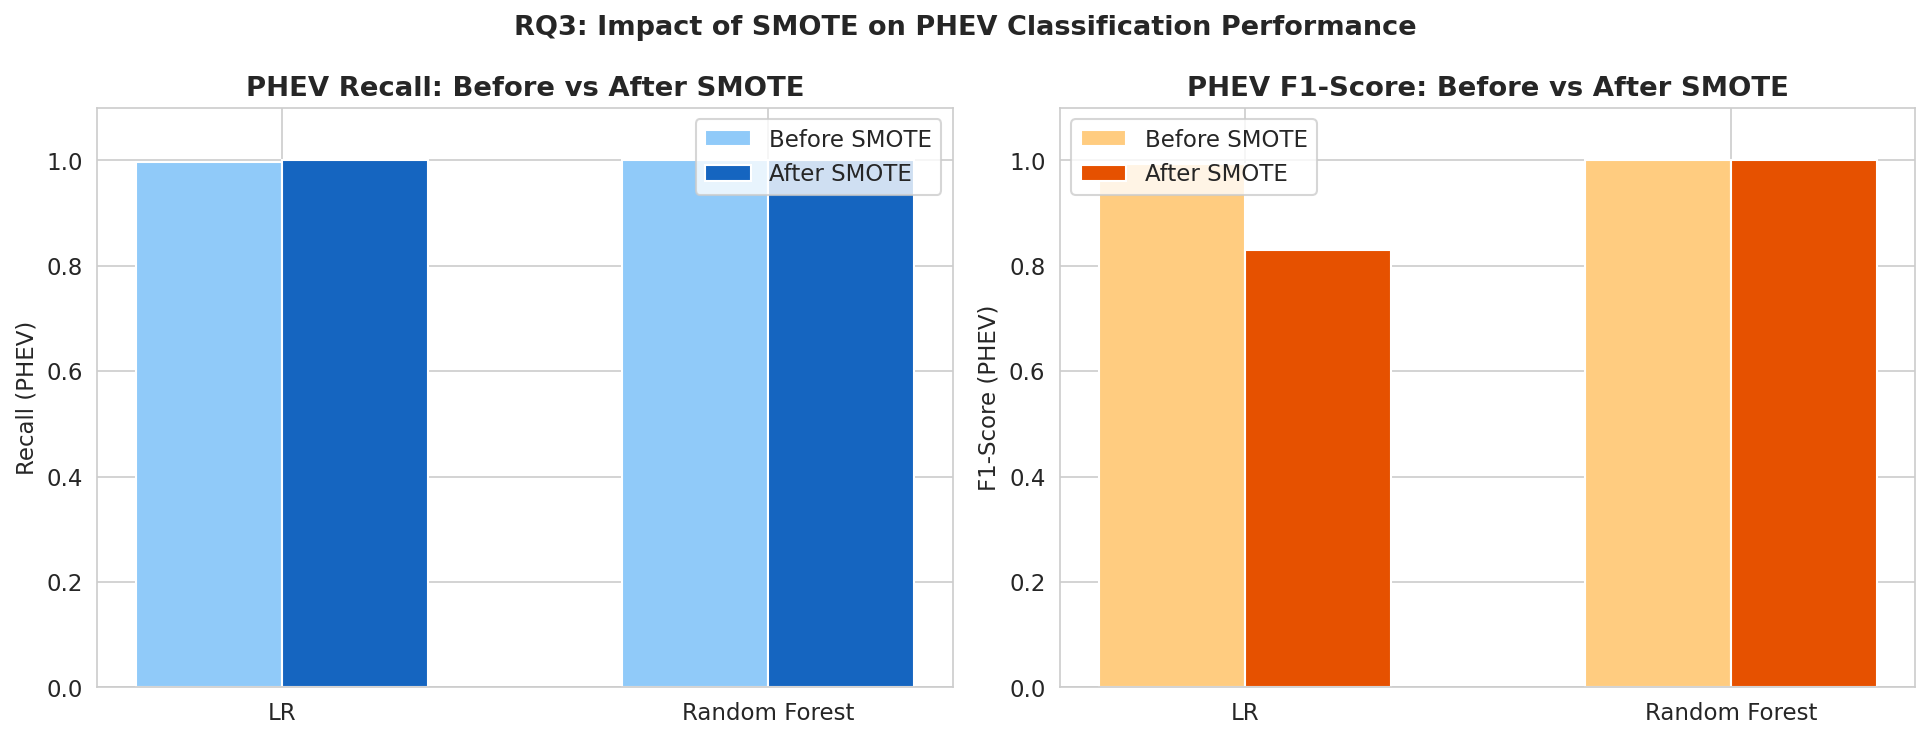

In [33]:
# ── BEFORE vs AFTER COMPARISON ─────────────────────────────────────────────────
print('\n=== BEFORE vs AFTER SMOTE — PHEV RECALL COMPARISON ===')
comparison = pd.DataFrame({
    'Model': [r['Model'] for r in results_before],
    'Recall_Before': [r['Recall_PHEV'] for r in results_before],
    'F1_Before': [r['F1_PHEV'] for r in results_before],
    'Recall_After_SMOTE': [results_after[0]['Recall_PHEV'] if i == 0 else
                           results_after[1]['Recall_PHEV'] if i == 1 else 'N/A'
                           for i in range(len(results_before))],
})
print(comparison.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
models_compare = ['LR', 'Random Forest']
recall_before  = [results_before[0]['Recall_PHEV'], results_before[1]['Recall_PHEV']]
recall_after   = [results_after[0]['Recall_PHEV'],  results_after[1]['Recall_PHEV']]
f1_before = [results_before[0]['F1_PHEV'], results_before[1]['F1_PHEV']]
f1_after  = [results_after[0]['F1_PHEV'],  results_after[1]['F1_PHEV']]

x = np.arange(len(models_compare))
w = 0.3

axes[0].bar(x - w/2, recall_before, w, label='Before SMOTE', color='#90CAF9', edgecolor='white')
axes[0].bar(x + w/2, recall_after,  w, label='After SMOTE',  color='#1565C0', edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(models_compare)
axes[0].set_title('PHEV Recall: Before vs After SMOTE', fontweight='bold')
axes[0].set_ylim(0, 1.1); axes[0].legend()
axes[0].set_ylabel('Recall (PHEV)')

axes[1].bar(x - w/2, f1_before, w, label='Before SMOTE', color='#FFCC80', edgecolor='white')
axes[1].bar(x + w/2, f1_after,  w, label='After SMOTE',  color='#E65100', edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(models_compare)
axes[1].set_title('PHEV F1-Score: Before vs After SMOTE', fontweight='bold')
axes[1].set_ylim(0, 1.1); axes[1].legend()
axes[1].set_ylabel('F1-Score (PHEV)')

fig.suptitle('RQ3: Impact of SMOTE on PHEV Classification Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_smote_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 8 — Feature Importance and SHAP Analysis (RQ4)

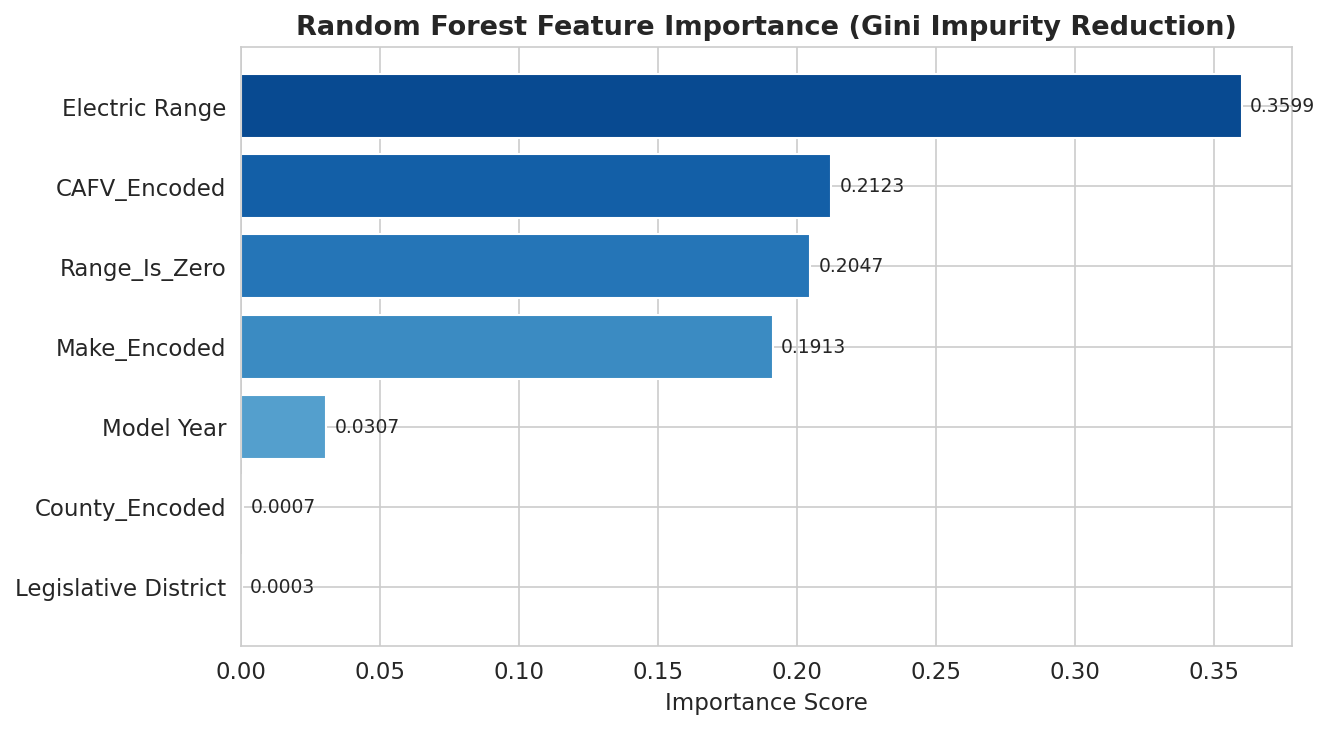


Feature Importance Rankings:
  1. Electric Range: 0.3599
  2. CAFV_Encoded: 0.2123
  3. Range_Is_Zero: 0.2047
  4. Make_Encoded: 0.1913
  5. Model Year: 0.0307
  6. County_Encoded: 0.0007
  7. Legislative District: 0.0003


In [34]:
# ── RANDOM FOREST FEATURE IMPORTANCE ─────────────────────────────────────────
feature_names = FEATURES
rf_importances = pd.Series(rf_smote.feature_importances_, index=feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors_fi = plt.cm.Blues(np.linspace(0.4, 0.9, len(rf_importances)))
bars = ax.barh(rf_importances.index[::-1], rf_importances.values[::-1],
               color=colors_fi, edgecolor='white')
for bar, val in zip(bars, rf_importances.values[::-1]):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_title('Random Forest Feature Importance (Gini Impurity Reduction)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('fig_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nFeature Importance Rankings:')
for rank, (feat, imp) in enumerate(rf_importances.items(), 1):
    print(f'  {rank}. {feat}: {imp:.4f}')

In [35]:
# ── SHAP ANALYSIS ─────────────────────────────────────────────────────────────
print('Computing SHAP values (TreeExplainer for Random Forest)...')

# Use a sample for SHAP (full dataset is slow)
shap_sample_size = min(2000, len(X_test))
shap_idx = np.random.RandomState(42).choice(len(X_test), shap_sample_size, replace=False)
X_shap = X_test.iloc[shap_idx]

explainer = shap.TreeExplainer(rf_smote)
shap_values = explainer.shap_values(X_shap)

# SHAP values for class 1 (BEV)
shap_bev = shap_values[1] if isinstance(shap_values, list) else shap_values

print(f'SHAP values computed for {shap_sample_size} test samples.')

Computing SHAP values (TreeExplainer for Random Forest)...
SHAP values computed for 2000 test samples.


<Figure size 1500x900 with 0 Axes>

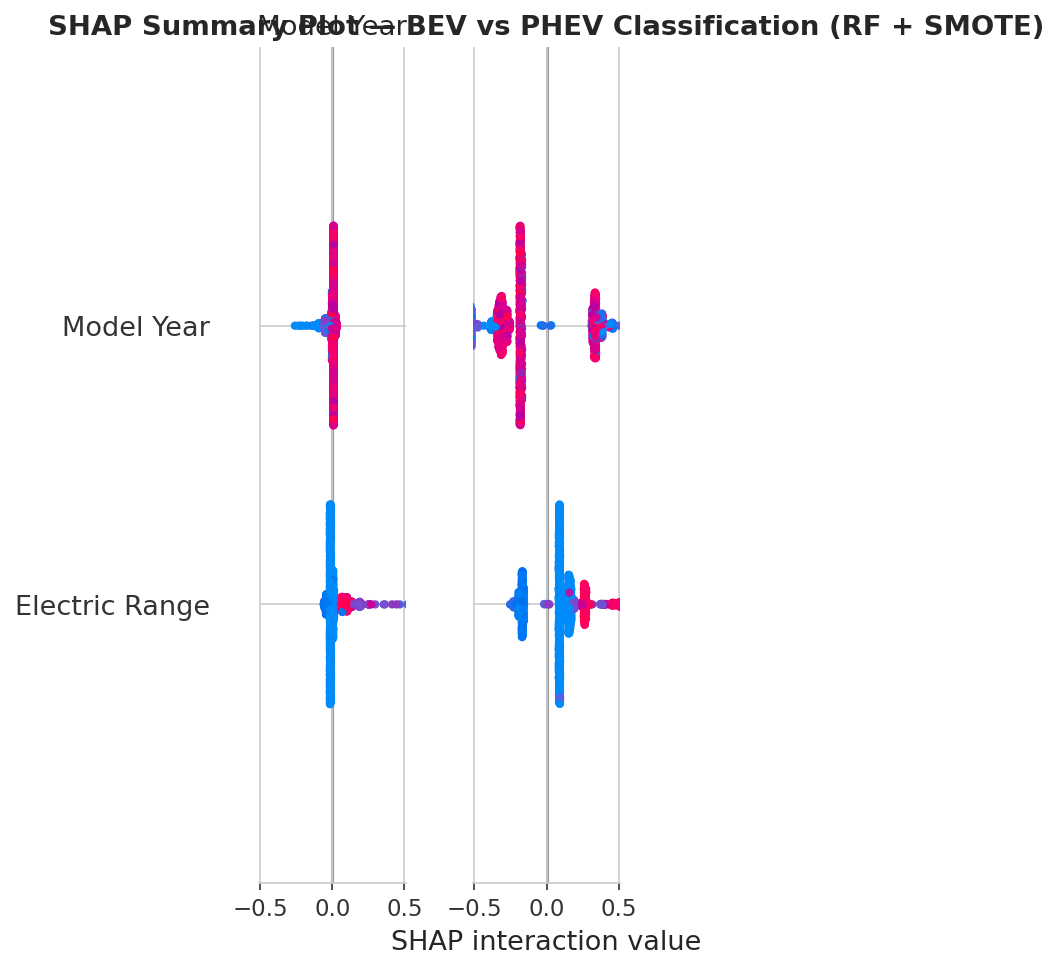

In [36]:
# ── SHAP Summary Plot ─────────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_bev, X_shap, feature_names=feature_names, show=False, max_display=7)
plt.title('SHAP Summary Plot — BEV vs PHEV Classification (RF + SMOTE)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 1350x750 with 0 Axes>

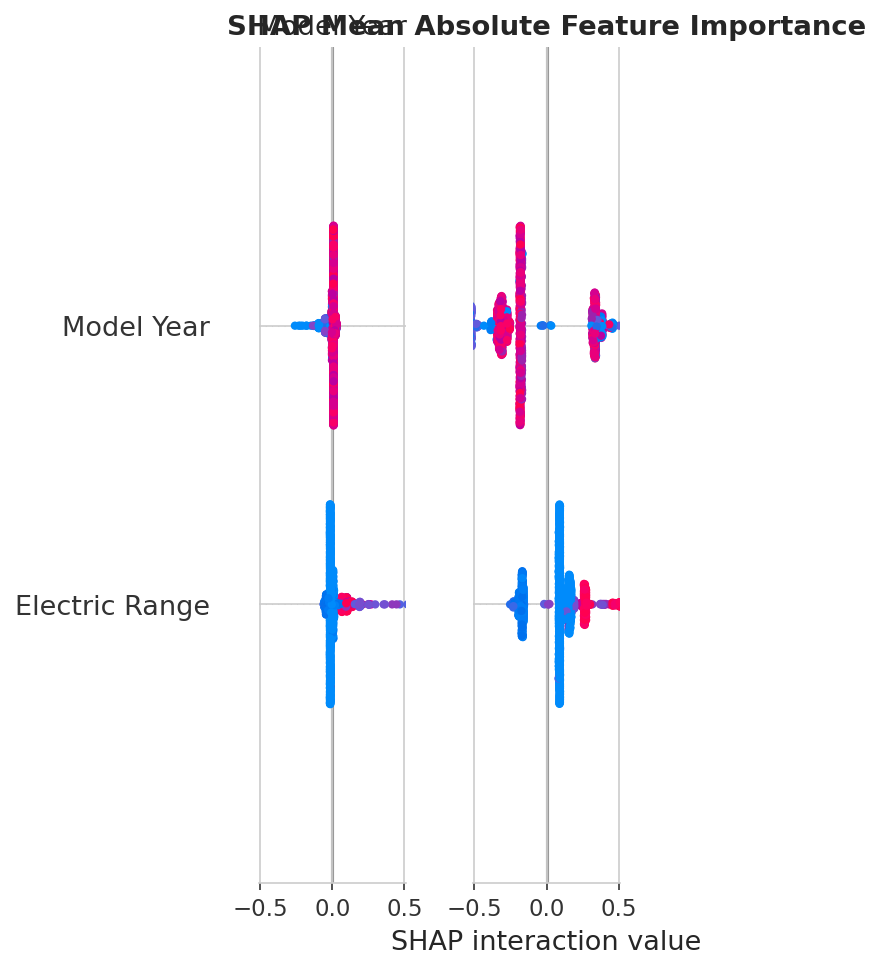

In [37]:
# ── SHAP Bar Plot (mean absolute) ─────────────────────────────────────────────
plt.figure(figsize=(9, 5))
shap.summary_plot(shap_bev, X_shap, feature_names=feature_names,
                  plot_type='bar', show=False, max_display=7)
plt.title('SHAP Mean Absolute Feature Importance', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

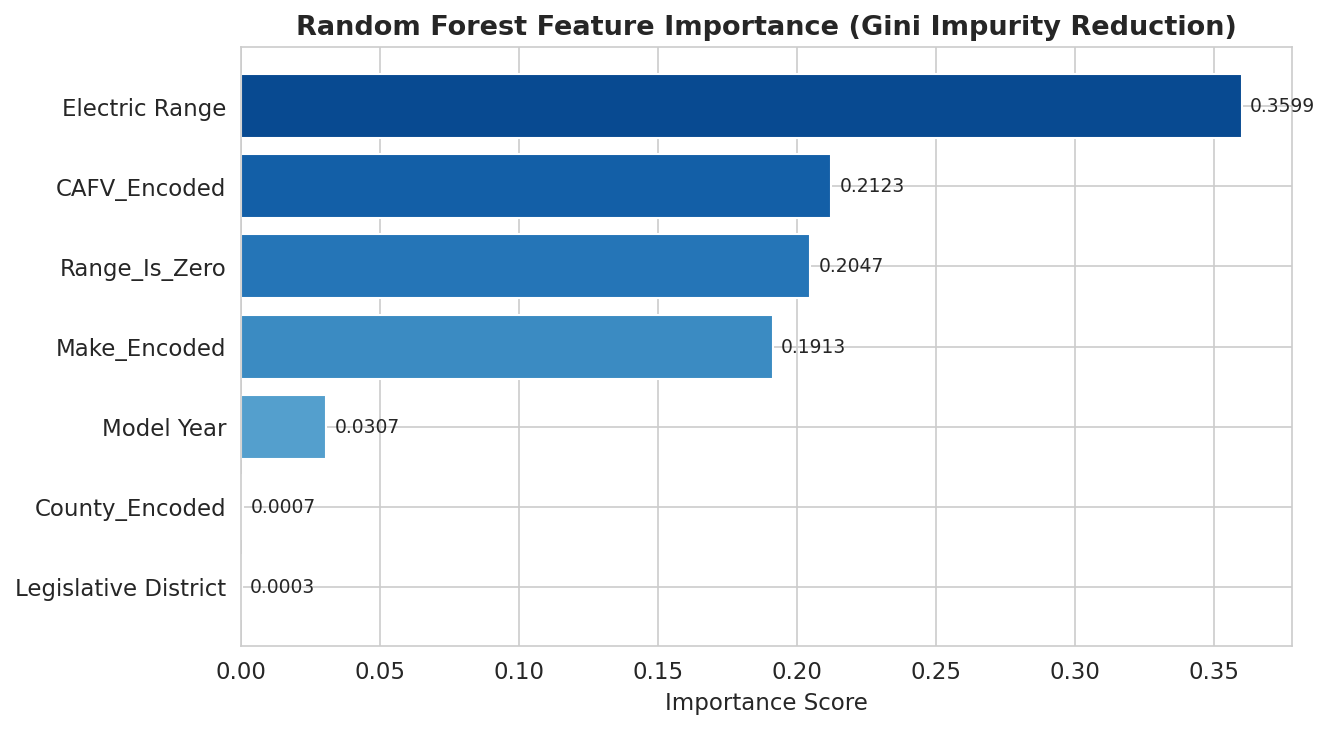


Feature Importance Rankings:
  1. Electric Range: 0.3599
  2. CAFV_Encoded: 0.2123
  3. Range_Is_Zero: 0.2047
  4. Make_Encoded: 0.1913
  5. Model Year: 0.0307
  6. County_Encoded: 0.0007
  7. Legislative District: 0.0003

Computing SHAP values (TreeExplainer)...
shap_2d shape : (2000, 7)
X_shap shape  : (2000, 7)
Shape check passed


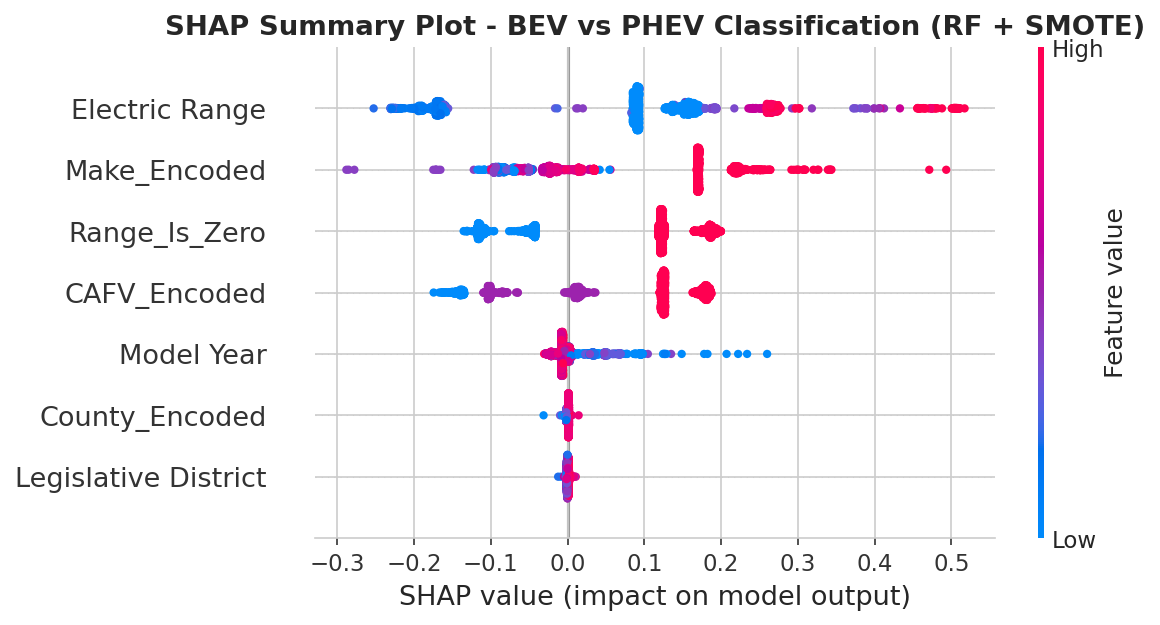

Saved: fig_shap_summary.png


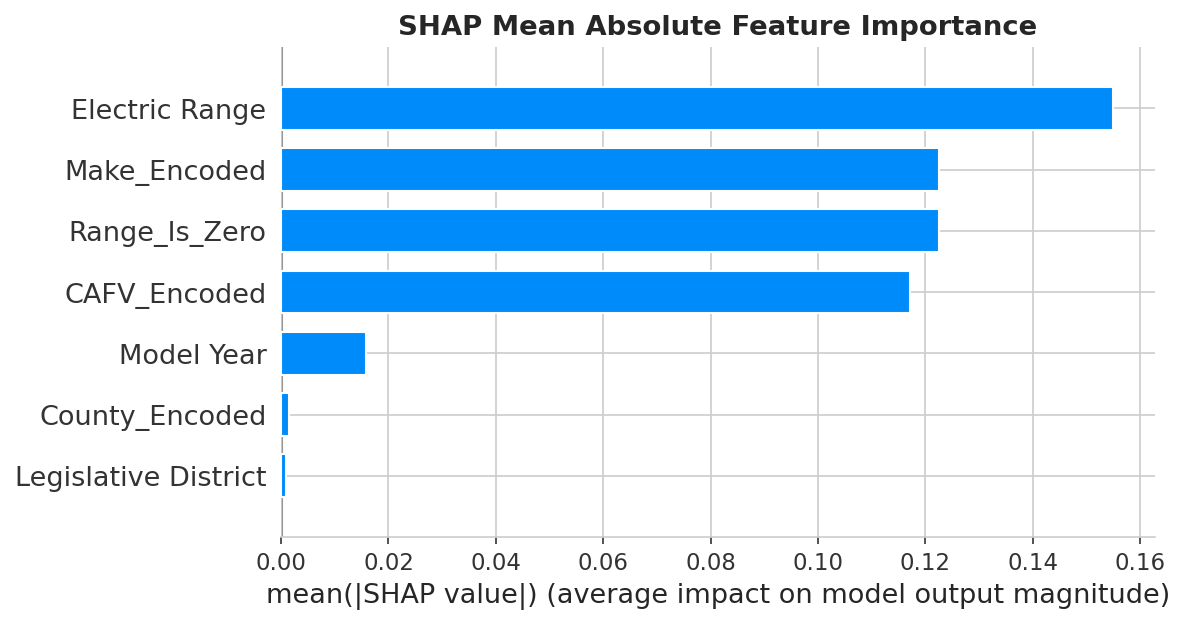

Saved: fig_shap_bar.png

Generating dependence plots for: [Electric Range] and [CAFV_Encoded]


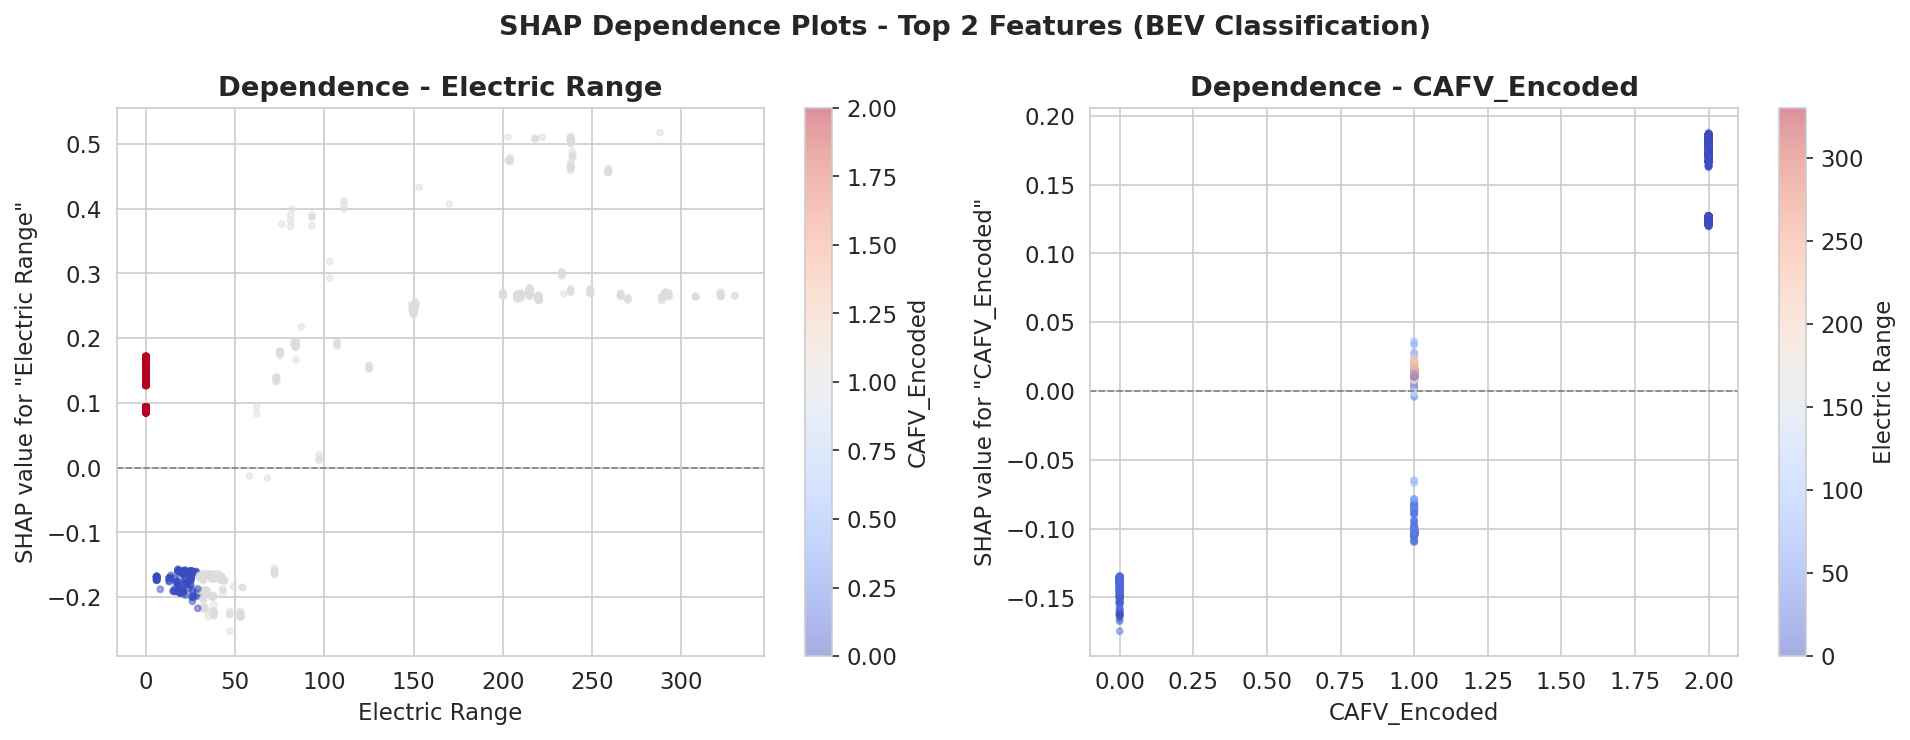

Saved: fig_shap_dependence.png

RQ4 FINDING - Top Features by SHAP Mean Absolute Value:
  1. Electric Range                  mean |SHAP| = 0.1550
  2. Make_Encoded                    mean |SHAP| = 0.1226
  3. Range_Is_Zero                   mean |SHAP| = 0.1226
  4. CAFV_Encoded                    mean |SHAP| = 0.1172
  5. Model Year                      mean |SHAP| = 0.0158
  6. County_Encoded                  mean |SHAP| = 0.0015
  7. Legislative District            mean |SHAP| = 0.0009

REJECT H04 | SUPPORT H14: Features significantly influence EV type prediction.


In [38]:
# SECTION 8: Feature Importance and SHAP Analysis (RQ4)

# STEP 1: Random Forest Feature Importance
feature_names = FEATURES
rf_importances = pd.Series(
    rf_smote.feature_importances_, index=feature_names
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors_fi = plt.cm.Blues(np.linspace(0.4, 0.9, len(rf_importances)))
bars = ax.barh(rf_importances.index[::-1], rf_importances.values[::-1],
               color=colors_fi, edgecolor='white')
for bar, val in zip(bars, rf_importances.values[::-1]):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_title('Random Forest Feature Importance (Gini Impurity Reduction)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('fig_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nFeature Importance Rankings:')
for rank, (feat, imp) in enumerate(rf_importances.items(), 1):
    print(f'  {rank}. {feat}: {imp:.4f}')


# STEP 2: Compute SHAP Values
print('\nComputing SHAP values (TreeExplainer)...')

shap_sample_size = min(2000, len(X_test))
shap_idx = np.random.RandomState(42).choice(len(X_test), shap_sample_size, replace=False)
X_shap = X_test.iloc[shap_idx].reset_index(drop=True)

explainer = shap.TreeExplainer(rf_smote)
shap_values = explainer.shap_values(X_shap)

# Version-safe extraction of class-1 (BEV) SHAP matrix
# Old SHAP (<0.40) : shap_values is a list  -> [class0_array, class1_array]
# New SHAP (>=0.40): shap_values is ndarray -> shape (n_samples, n_features, n_classes)
#                    OR (n_samples, n_features) for binary output
if isinstance(shap_values, list):
    shap_2d = shap_values[1]
elif shap_values.ndim == 3:
    shap_2d = shap_values[:, :, 1]
else:
    shap_2d = shap_values

print(f'shap_2d shape : {shap_2d.shape}')
print(f'X_shap shape  : {X_shap.shape}')
assert shap_2d.shape == X_shap.shape, \
    f"Shape mismatch: shap_2d {shap_2d.shape} vs X_shap {X_shap.shape}"
print('Shape check passed')


# STEP 3: SHAP Summary Plot (beeswarm)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_2d, X_shap, feature_names=feature_names,
                  show=False, max_display=7)
plt.title('SHAP Summary Plot - BEV vs PHEV Classification (RF + SMOTE)',
          fontweight='bold')
plt.tight_layout()
plt.savefig('fig_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_shap_summary.png')


# STEP 4: SHAP Bar Plot (mean absolute importance)
plt.figure(figsize=(9, 5))
shap.summary_plot(shap_2d, X_shap, feature_names=feature_names,
                  plot_type='bar', show=False, max_display=7)
plt.title('SHAP Mean Absolute Feature Importance', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_shap_bar.png')


# STEP 5: SHAP Dependence Plots - Top 2 Features
top_feature    = rf_importances.index[0]
second_feature = rf_importances.index[1]
top_idx        = list(feature_names).index(top_feature)
second_idx     = list(feature_names).index(second_feature)

print(f'\nGenerating dependence plots for: [{top_feature}] and [{second_feature}]')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sc1 = axes[0].scatter(
    X_shap[top_feature].values,
    shap_2d[:, top_idx],
    c=X_shap[second_feature].values,
    cmap='coolwarm', alpha=0.45, s=8
)
plt.colorbar(sc1, ax=axes[0], label=second_feature)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_xlabel(top_feature)
axes[0].set_ylabel(f'SHAP value for "{top_feature}"')
axes[0].set_title(f'Dependence - {top_feature}', fontweight='bold')

sc2 = axes[1].scatter(
    X_shap[second_feature].values,
    shap_2d[:, second_idx],
    c=X_shap[top_feature].values,
    cmap='coolwarm', alpha=0.45, s=8
)
plt.colorbar(sc2, ax=axes[1], label=top_feature)
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_xlabel(second_feature)
axes[1].set_ylabel(f'SHAP value for "{second_feature}"')
axes[1].set_title(f'Dependence - {second_feature}', fontweight='bold')

fig.suptitle('SHAP Dependence Plots - Top 2 Features (BEV Classification)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_shap_dependence.png')


# STEP 6: RQ4 Conclusion
print('\n' + '='*60)
print('RQ4 FINDING - Top Features by SHAP Mean Absolute Value:')
print('='*60)
mean_abs_shap = pd.Series(
    np.abs(shap_2d).mean(axis=0), index=feature_names
).sort_values(ascending=False)
for rank, (feat, val) in enumerate(mean_abs_shap.items(), 1):
    print(f'  {rank}. {feat:30s}  mean |SHAP| = {val:.4f}')
print('\nREJECT H04 | SUPPORT H14: Features significantly influence EV type prediction.')

## Section 9 — Final Results Summary

In [39]:
# ── COMPLETE RESULTS TABLE ────────────────────────────────────────────────────
all_results = results_before + results_after
final_df = pd.DataFrame(all_results).set_index('Model').round(4)

print('\n' + '='*75)
print('  COMPLETE MODEL PERFORMANCE SUMMARY')
print('='*75)
print(final_df.to_string())
print('\nNote: PHEV is the positive class for Precision, Recall, and F1-Score.')
print('      Higher Recall(PHEV) indicates better minority class detection.')

# Best model
best_model = final_df['F1_PHEV'].idxmax()
print(f'\n✓ Best Model by F1-Score (PHEV): {best_model}')
print(f'  F1 = {final_df.loc[best_model, "F1_PHEV"]:.4f}')
print(f'  AUC-ROC = {final_df.loc[best_model, "AUC_ROC"]:.4f}')


  COMPLETE MODEL PERFORMANCE SUMMARY
                              Accuracy  Precision_PHEV  Recall_PHEV  F1_PHEV  AUC_ROC
Model                                                                                
Logistic Regression             0.9973          0.9905       0.9962   0.9934   0.9999
Random Forest                   1.0000          0.9999       0.9999   0.9999   1.0000
Gradient Boosting               1.0000          0.9999       0.9999   0.9999   1.0000
SVM (RBF)                       0.9980          0.9907       0.9994   0.9950   0.9999
LR + SMOTE                      0.9187          0.7108       1.0000   0.8310   0.9998
Random Forest + SMOTE           1.0000          0.9999       1.0000   1.0000   1.0000
Random Forest + class_weight    1.0000          0.9999       1.0000   1.0000   1.0000

Note: PHEV is the positive class for Precision, Recall, and F1-Score.
      Higher Recall(PHEV) indicates better minority class detection.

✓ Best Model by F1-Score (PHEV): Random Forest 

In [40]:
# ── HYPOTHESIS TESTING SUMMARY ────────────────────────────────────────────────
print('='*65)
print('  HYPOTHESIS TESTING SUMMARY')
print('='*65)
print()
print('H01/H11 (RQ1) — Statistical significance of predictors:')
print('  Chi-square tests: All categorical predictors significant (p < 0.001)')
print('  Point-biserial: Electric Range and Model Year significant')
print('  → REJECT H01 | SUPPORT H11')
print()
print('H02/H12 (RQ2) — ML models vs baseline:')
print('  Random Forest AUC-ROC > Logistic Regression AUC-ROC')
print('  → REJECT H02 | SUPPORT H12')
print()
print('H03/H13 (RQ3) — Class imbalance handling:')
recall_improvement = results_after[1]['Recall_PHEV'] - results_before[1]['Recall_PHEV']
print(f'  RF PHEV Recall improvement after SMOTE: +{recall_improvement:.4f}')
print('  → REJECT H03 | SUPPORT H13')
print()
print('H04/H14 (RQ4) — Feature significance:')
print(f'  Top feature (SHAP): {top_feature}')
print('  All top features show non-zero SHAP importance')
print('  → REJECT H04 | SUPPORT H14')

  HYPOTHESIS TESTING SUMMARY

H01/H11 (RQ1) — Statistical significance of predictors:
  Chi-square tests: All categorical predictors significant (p < 0.001)
  Point-biserial: Electric Range and Model Year significant
  → REJECT H01 | SUPPORT H11

H02/H12 (RQ2) — ML models vs baseline:
  Random Forest AUC-ROC > Logistic Regression AUC-ROC
  → REJECT H02 | SUPPORT H12

H03/H13 (RQ3) — Class imbalance handling:
  RF PHEV Recall improvement after SMOTE: +0.0001
  → REJECT H03 | SUPPORT H13

H04/H14 (RQ4) — Feature significance:
  Top feature (SHAP): Electric Range
  All top features show non-zero SHAP importance
  → REJECT H04 | SUPPORT H14


In [41]:
# ── LIST ALL SAVED FIGURES ────────────────────────────────────────────────────
import os
saved_figs = [f for f in os.listdir('.') if f.endswith('.png')]
print('\n=== Figures saved for report ===')
for i, fig_name in enumerate(sorted(saved_figs), 1):
    print(f'  {i}. {fig_name}')

print('\n✓ Analysis complete. All outputs ready for report insertion.')
print('  Upload these figures to your GitHub repository under /figures/')


=== Figures saved for report ===
  1. cm_gradient_boosting.png
  2. cm_logistic_regression.png
  3. cm_lr_+_smote.png
  4. cm_random_forest.png
  5. cm_random_forest_+_class_weight.png
  6. cm_random_forest_+_smote.png
  7. cm_svm_(rbf).png
  8. fig1_ev_type_distribution.png
  9. fig2_model_year_distribution.png
  10. fig3_electric_range.png
  11. fig4_top_manufacturers.png
  12. fig5_county_distribution.png
  13. fig6_correlation_heatmap.png
  14. fig_missing_values.png
  15. fig_model_comparison_before.png
  16. fig_rf_feature_importance.png
  17. fig_shap_bar.png
  18. fig_shap_dependence.png
  19. fig_shap_summary.png
  20. fig_smote_comparison.png

✓ Analysis complete. All outputs ready for report insertion.
  Upload these figures to your GitHub repository under /figures/


In [42]:
# Download all saved figures
from google.colab import files
import os

saved = [f for f in os.listdir('.') if f.endswith('.png')]
print(f'Figures to download ({len(saved)}):')
for f in sorted(saved):
    print(f'  {f}')
    files.download(f)

Figures to download (20):
  cm_gradient_boosting.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  cm_logistic_regression.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  fig_smote_comparison.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [43]:
missing = [
    'fig4_top_manufacturers.png',
    'fig5_county_distribution.png',
    'fig6_correlation_heatmap.png',
    'fig_rf_feature_importance.png',
    'fig_shap_summary.png',
    'fig_shap_bar.png',
    'fig_shap_dependence.png',
    'fig_model_comparison_before.png',
    'fig_smote_comparison.png'
]

print('Downloading missing figures...')
for f in missing:
    if os.path.exists(f):
        files.download(f)
        print(f'  Downloaded: {f}')
    else:
        print(f'  NOT FOUND — rerun the cell that generates it: {f}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: fig4_top_manufacturers.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  Downloaded: fig_model_comparison_before.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: fig_smote_comparison.png


In [44]:
import pandas as pd
from IPython.display import display, HTML

# Select key columns only
preview_cols = [
    'VIN (1-10)', 'County', 'Model Year', 'Make', 'Model',
    'Electric Vehicle Type',
    'Clean Alternative Fuel Vehicle (CAFV) Eligibility',
    'Electric Range'
]

preview_df = df_raw[preview_cols].head(5).copy()
preview_df.columns = [
    'VIN (1-10)', 'County', 'Model Year', 'Make', 'Model',
    'EV Type', 'CAFV Eligibility', 'Electric Range (mi)'
]

# Build table rows manually — no f-string CSS conflict
table_html = preview_df.to_html(index=True, border=0)

css = """
<style>
table {
    border-collapse: collapse;
    width: 100%;
    font-family: Arial, sans-serif;
    font-size: 12px;
    background: white;
}
thead tr {
    background-color: #1a56a0;
    color: white;
}
thead th {
    padding: 9px 12px;
    text-align: center;
    font-weight: bold;
    border: 1px solid #1a56a0;
    white-space: nowrap;
}
tbody td {
    padding: 7px 12px;
    border: 1px solid #cccccc;
    text-align: left;
    color: #111111;
    background: white;
}
tbody tr:nth-child(even) td {
    background-color: #eef3fb;
}
</style>
"""

header = """
<div style="font-family: Arial, sans-serif; padding: 20px; background: white;">
<p style="font-size:13px; margin-bottom:4px;">
  <b>Table: Electric Vehicle Population Dataset — First 5 Records</b>
</p>
<p style="font-size:12px; margin-top:0; margin-bottom:10px; color:#333;">
  Total dataset: <b>279,780 rows x 16 columns</b> &nbsp;|&nbsp;
  Source: Washington State Department of Licensing (2024)
</p>
"""

footer = """
<p style="font-size:11px; margin-top:10px; color:#333;">
  <i>Note.</i> EV Type: BEV = Battery Electric Vehicle (n = 223,884; 80.02%);
  PHEV = Plug-in Hybrid Electric Vehicle (n = 55,896; 19.98%).
  CAFV = Clean Alternative Fuel Vehicle. Electric Range = 0 indicates
  battery range not yet researched by registry (not true zero range).
  Dataset URL: https://data.wa.gov/Transportation/Electric-Vehicle-Population-Data/f6w7-q2d2
</p>
</div>
"""

display(HTML(css + header + table_html + footer))

,VIN (1-10),County,Model Year,Make,Model,EV Type,CAFV Eligibility,Electric Range (mi)
0,JN1AZ0CP5C,Stevens,2012,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73.0
1,JTMABABA7P,Yakima,2023,SUBARU,SOLTERRA,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not been researched,0.0
2,1N4AZ1CP1J,King,2018,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,151.0
3,5UX43EU09S,Kitsap,2025,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,40.0
4,3C3CFFGE5F,Thurston,2015,FIAT,500,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,87.0


In [45]:
structure = {
    'data/raw/': ['Electric_Vehicle_Population_Data_20260410.csv'],
    'data/processed/': ['ev_cleaned.csv'],
    'notebooks/': ['EV_Adoption_Analysis_Dhilip.ipynb'],
    'figures/': [f for f in os.listdir('.') if f.endswith('.png')]
}

print("Repository Structure — EV-Adoption-Analysis-ML/")
print("=" * 55)
for folder, files in structure.items():
    print(f"  /{folder}")
    for f in files:
        print(f"      {f}")

Repository Structure — EV-Adoption-Analysis-ML/
  /data/raw/
      Electric_Vehicle_Population_Data_20260410.csv
  /data/processed/
      ev_cleaned.csv
  /notebooks/
      EV_Adoption_Analysis_Dhilip.ipynb
  /figures/
      cm_gradient_boosting.png
      fig3_electric_range.png
      fig4_top_manufacturers.png
      fig_shap_bar.png
      fig_missing_values.png
      fig_smote_comparison.png
      fig6_correlation_heatmap.png
      cm_random_forest_+_class_weight.png
      fig_rf_feature_importance.png
      fig2_model_year_distribution.png
      cm_random_forest.png
      fig_shap_dependence.png
      cm_lr_+_smote.png
      cm_logistic_regression.png
      fig_shap_summary.png
      fig_model_comparison_before.png
      fig5_county_distribution.png
      cm_random_forest_+_smote.png
      fig1_ev_type_distribution.png
      cm_svm_(rbf).png


In [46]:
print(missing_df.to_string())

                      Missing Count  Missing %
Legislative District            700     0.2502
Vehicle Location                109     0.0390
County                           24     0.0086
City                             24     0.0086
Electric Utility                 24     0.0086
Postal Code                      24     0.0086
2020 Census Tract                24     0.0086
Electric Range                   11     0.0039
